In [1]:
import entropy_utils
import numpy as np
import random
import pickle
import copy

import jax
from jax.config import config
config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu')


import jax.numpy as jaxnp
from jax import grad, jit, vmap
from functools import partial
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd 
import scipy
import sys

In [2]:
# unnormalized probability for having key element

# weights need to be discussed
# 1 H 
# 6 noble gas elements
# 35 sp block elements, first 14 most common
# about 30 sd block elements
# what to do with all the other elements ?


# currently: took out magnetic 3d elements and f elements
"""
species_prob = {
'H': 10.0,
'He': 1.0,
'Li': 5.0,
'Be': 5.0,
'B': 5.0,
'C': 10.0,
'N': 5.0,
'O': 5.0,
'F': 5.0,
'Ne': 1.0,
'Na': 5.0,
'Mg': 5.0,
'Al': 5.0,
'Si': 5.0,
'P': 5.0,
'S': 5.0,
'Cl': 5.0,
'Ar': 1.0,
'K': 1.0,
'Ca': 1.0,
'Sc': 1.0,
'Ti': 1.0,
'V': 1.0,
'Cr': 0.0,
'Mn': 0.0,
'Fe': 0.0,
'Co': 0.0,
'Ni': 0.0,
'Cu': 1.0,
'Zn': 2.0,
'Ga': 2.0,
'Ge': 2.0,
'As': 2.0,
'Se': 2.0,
'Br': 2.0,
'Kr': 1.0,
'Rb': 1.0,
'Sr': 1.0,
'Y': 1.0,
'Zr': 1.0,
'Nb': 1.0,
'Mo': 1.0,
'Tc': 1.0,
'Ru': 1.0,
'Rh': 1.0,
'Pd': 1.0,
'Ag': 1.0,
'Cd': 1.0,
'In': 1.0,
'Sn': 1.0,
'Sb': 1.0,
'Te': 1.0,
'I': 1.0,
'Xe': 1.0,
'Cs': 0.0,
'Ba': 0.0,
'La': 0.0,
'Ce': 0.0,
'Pr': 0.0,
'Nd': 0.0,
'Pm': 0.0,
'Sm': 0.0,
'Eu': 0.0,
'Gd': 0.0,
'Tb': 0.0,
'Dy': 0.0,
'Ho': 0.0,
'Er': 0.0,
'Tm': 0.0,
'Yb': 0.0,
'Lu': 0.0,
'Hf': 1.0,
'Ta': 1.0,
'W': 1.0,
'Re': 1.0,
'Os': 1.0,
'Ir': 1.0,
'Pt': 1.0,
'Au': 1.0,
'Hg': 1.0,
'Tl': 1.0,
'Pb': 1.0,
'Bi': 1.0,
'Po': 1.0,
'At': 1.0,
'Rn': 1.0,
'Fr': 0.0,
'Ra': 0.0,
'Ac': 0.0,
'Th': 0.0,
'Pa': 0.0,
'U': 0.0,
'Np': 0.0,
'Pu': 0.0,
'Am': 0.0,
'Cm': 0.0,
'Bk': 0.0,
'Cf': 0.0,
'Es': 0.0,
'Fm': 0.0,
'Md': 0.0,
'No': 0.0,
'Lr': 0.0,
'Rf': 0.0,
'Db': 0.0,
'Sg': 0.0,
'Bh': 0.0,
'Hs': 0.0,
'Mt': 0.0,
'Ds': 0.0,
'Rg': 0.0,
'Cn': 0.0,
'Nh': 0.0,
'Fl': 0.0,
'Mc': 0.0,
'Lv': 0.0,
'Ts': 0.0,
'Og': 0.0
}
"""
# unnormalized probability for having key element

# weights need to be discussed
# 1 H 
# 6 noble gas elements
# 35 sp block elements, first 14 most common
# about 30 sd block elements
# what to do with all the other elements ?

#GRACE STANDARD
"""
species_prob = {
'H': 10.0,
'He': 1.0,
'Li': 5.0,
'Be': 5.0,
'B': 5.0,
'C': 10.0,
'N': 5.0,
'O': 5.0,
'F': 5.0,
'Ne': 1.0,
'Na': 5.0,
'Mg': 5.0,
'Al': 5.0,
'Si': 5.0,
'P': 5.0,
'S': 5.0,
'Cl': 5.0,
'Ar': 1.0,
'K': 1.0,
'Ca': 1.0,
'Sc': 1.0,
'Ti': 1.0,
'V': 1.0,
'Cr': 1.0,
'Mn': 1.0,
'Fe': 1.0,
'Co': 1.0,
'Ni': 1.0,
'Cu': 1.0,
'Zn': 2.0,
'Ga': 2.0,
'Ge': 2.0,
'As': 2.0,
'Se': 2.0,
'Br': 2.0,
'Kr': 1.0,
'Rb': 1.0,
'Sr': 1.0,
'Y': 1.0,
'Zr': 1.0,
'Nb': 1.0,
'Mo': 1.0,
'Tc': 1.0,
'Ru': 1.0,
'Rh': 1.0,
'Pd': 1.0,
'Ag': 1.0,
'Cd': 1.0,
'In': 1.0,
'Sn': 1.0,
'Sb': 1.0,
'Te': 1.0,
'I': 1.0,
'Xe': 1.0,
'Cs': 0.5,
'Ba': 0.5,
'La': 0.5,
'Ce': 0.5,
'Pr': 0.5,
'Nd': 0.5,
'Pm': 0.5,
'Sm': 0.5,
'Eu': 0.5,
'Gd': 0.5,
'Tb': 0.5,
'Dy': 0.5,
'Ho': 0.5,
'Er': 0.5,
'Tm': 0.5,
'Yb': 0.5,
'Lu': 0.5,
'Hf': 1.0,
'Ta': 1.0,
'W': 1.0,
'Re': 1.0,
'Os': 1.0,
'Ir': 1.0,
'Pt': 1.0,
'Au': 1.0,
'Hg': 1.0,
'Tl': 1.0,
'Pb': 1.0,
'Bi': 1.0,
'Po': 1.0,
'At': 0.5,
'Rn': 0.5,
'Fr': 0.5,
'Ra': 0.5,
'Ac': 0.5,
'Th': 0.5,
'Pa': 0.5,
'U': 0.5,
'Np': 0.5,
'Pu': 0.5,
'Am': 0.5,
'Cm': 0.5,
'Bk': 0.0,
'Cf': 0.0,
'Es': 0.0,
'Fm': 0.0,
'Md': 0.0,
'No': 0.0,
'Lr': 0.0,
'Rf': 0.0,
'Db': 0.0,
'Sg': 0.0,
'Bh': 0.0,
'Hs': 0.0,
'Mt': 0.0,
'Ds': 0.0,
'Rg': 0.0,
'Cn': 0.0,
'Nh': 0.0,
'Fl': 0.0,
'Mc': 0.0,
'Lv': 0.0,
'Ts': 0.0,
'Og': 0.0
}

"""

#LANL URANIUM SET

w_actinides=1.0
w_lanthanides=1.0
w_fission=1.0
w_gas=1.0
w_other=1.0
w_uranium=1000.

species_prob = {
'H': w_gas,
'He': w_gas,
'Li': w_fission,
'Be': w_other,
'B': w_other,
'C': w_other,
'N': w_other,
'O': w_other,
'F': w_other,
'Ne': w_gas,
'Na': w_other,
'Mg': w_other,
'Al': w_other,
'Si': w_other,
'P': w_other,
'S': w_other,
'Cl': w_other,
'Ar': w_gas,
'K': w_fission,
'Ca': w_fission,
'Sc': w_other,
'Ti': w_other,
'V': w_other,
'Cr': w_other,
'Mn': w_other,
'Fe': w_other,
'Co': w_other,
'Ni': w_other,
'Cu': w_other,
'Zn': w_other,
'Ga': w_other,
'Ge': w_other,
'As': w_other,
'Se': w_fission,
'Br': w_fission,
'Kr': w_gas,
'Rb': w_fission,
'Sr': w_fission,
'Y': w_fission,
'Zr': w_fission,
'Nb': w_other,
'Mo': w_fission,
'Tc': w_fission,
'Ru': w_fission,
'Rh': w_fission,
'Pd': w_fission,
'Ag': w_fission,
'Cd': w_other,
'In': w_other,
'Sn': w_fission,
'Sb': w_fission,
'Te': w_fission,
'I': w_fission,
'Xe': w_gas,
'Cs': w_fission,
'Ba': w_fission,
'La': w_lanthanides,
'Ce': w_lanthanides,
'Pr': w_lanthanides,
'Nd': w_lanthanides,
'Pm': w_lanthanides,
'Sm': w_lanthanides,
'Eu': w_lanthanides,
'Gd': w_lanthanides,
'Tb': w_lanthanides,
'Dy': w_lanthanides,
'Ho': w_lanthanides,
'Er': w_lanthanides,
'Tm': w_lanthanides,
'Yb': w_lanthanides,
'Lu': w_lanthanides,
'Hf': w_other,
'Ta': w_other,
'W': w_other,
'Re': w_other,
'Os': w_other,
'Ir': w_other,
'Pt': w_other,
'Au': w_other,
'Hg': w_other,
'Tl': w_other,
'Pb': w_other,
'Bi': w_other,
'Po': w_other,
'At': w_other,
'Rn': w_other,
'Fr': w_other,
'Ra': w_gas,
'Ac': w_actinides,
'Th': w_actinides,
'Pa': w_actinides,
'U': w_uranium,
'Np': w_actinides,
'Pu': w_actinides,
'Am': w_actinides,
'Cm': w_actinides,
'Bk': 0.0,
'Cf': 0.0,
'Es': 0.0,
'Fm': 0.0,
'Md': 0.0,
'No': 0.0,
'Lr': 0.0,
'Rf': 0.0,
'Db': 0.0,
'Sg': 0.0,
'Bh': 0.0,
'Hs': 0.0,
'Mt': 0.0,
'Ds': 0.0,
'Rg': 0.0,
'Cn': 0.0,
'Nh': 0.0,
'Fl': 0.0,
'Mc': 0.0,
'Lv': 0.0,
'Ts': 0.0,
'Og': 0.0
}

"""
#LANL MISSION SET

w_actinides=3.0
w_lanthanides=3.0
w_fission=2.0
w_gas=2.0
w_other=1.0

species_prob = {
'H': w_gas,
'He': w_gas,
'Li': w_fission,
'Be': w_other,
'B': w_other,
'C': w_other,
'N': w_other,
'O': w_other,
'F': w_other,
'Ne': w_gas,
'Na': w_other,
'Mg': w_other,
'Al': w_other,
'Si': w_other,
'P': w_other,
'S': w_other,
'Cl': w_other,
'Ar': w_gas,
'K': w_fission,
'Ca': w_fission,
'Sc': w_other,
'Ti': w_other,
'V': w_other,
'Cr': w_other,
'Mn': w_other,
'Fe': w_other,
'Co': w_other,
'Ni': w_other,
'Cu': w_other,
'Zn': w_other,
'Ga': w_other,
'Ge': w_other,
'As': w_other,
'Se': w_fission,
'Br': w_fission,
'Kr': w_gas,
'Rb': w_fission,
'Sr': w_fission,
'Y': w_fission,
'Zr': w_fission,
'Nb': w_other,
'Mo': w_fission,
'Tc': w_fission,
'Ru': w_fission,
'Rh': w_fission,
'Pd': w_fission,
'Ag': w_fission,
'Cd': w_other,
'In': w_other,
'Sn': w_fission,
'Sb': w_fission,
'Te': w_fission,
'I': w_fission,
'Xe': w_gas,
'Cs': w_fission,
'Ba': w_fission,
'La': w_lanthanides,
'Ce': w_lanthanides,
'Pr': w_lanthanides,
'Nd': w_lanthanides,
'Pm': w_lanthanides,
'Sm': w_lanthanides,
'Eu': w_lanthanides,
'Gd': w_lanthanides,
'Tb': w_lanthanides,
'Dy': w_lanthanides,
'Ho': w_lanthanides,
'Er': w_lanthanides,
'Tm': w_lanthanides,
'Yb': w_lanthanides,
'Lu': w_lanthanides,
'Hf': w_other,
'Ta': w_other,
'W': w_other,
'Re': w_other,
'Os': w_other,
'Ir': w_other,
'Pt': w_other,
'Au': w_other,
'Hg': w_other,
'Tl': w_other,
'Pb': w_other,
'Bi': w_other,
'Po': w_other,
'At': w_other,
'Rn': w_other,
'Fr': w_other,
'Ra': w_gas,
'Ac': w_actinides,
'Th': w_actinides,
'Pa': w_actinides,
'U': w_actinides,
'Np': w_actinides,
'Pu': w_actinides,
'Am': w_actinides,
'Cm': w_actinides,
'Bk': 0.0,
'Cf': 0.0,
'Es': 0.0,
'Fm': 0.0,
'Md': 0.0,
'No': 0.0,
'Lr': 0.0,
'Rf': 0.0,
'Db': 0.0,
'Sg': 0.0,
'Bh': 0.0,
'Hs': 0.0,
'Mt': 0.0,
'Ds': 0.0,
'Rg': 0.0,
'Cn': 0.0,
'Nh': 0.0,
'Fl': 0.0,
'Mc': 0.0,
'Lv': 0.0,
'Ts': 0.0,
'Og': 0.0
}
"""

"""
#REFRACTORY SET
species_prob = {
'H': 1.0,
'He': 1.0,
'Li': 0.1,
'Be': 0.1,
'B': 0.1,
'C': 0.1,
'N': 0.1,
'O': 0.1,
'F': 0.1,
'Ne': 0.1,
'Na': 0.1,
'Mg': 0.1,
'Al': 0.1,
'Si': 0.1,
'P': 0.1,
'S': 0.1,
'Cl': 0.1,
'Ar': 0.1,
'K': 0.1,
'Ca': 0.1,
'Sc': 0.1,
'Ti': 1.0,
'V': 1.0,
'Cr': 1.0,
'Mn': 0.1,
'Fe': 0.1,
'Co': 0.1,
'Ni': 0.1,
'Cu': 0.1,
'Zn': 0.1,
'Ga': 0.1,
'Ge': 0.1,
'As': 0.1,
'Se': 0.1,
'Br': 0.1,
'Kr': 0.1,
'Rb': 0.1,
'Sr': 0.1,
'Y': 0.1,
'Zr': 1.0,
'Nb': 1.0,
'Mo': 1.0,
'Tc': 1.0,
'Ru': 1.0,
'Rh': 1.0,
'Pd': 0.1,
'Ag': 0.1,
'Cd': 0.1,
'In': 0.1,
'Sn': 0.1,
'Sb': 0.1,
'Te': 0.1,
'I': 0.1,
'Xe': 0.1,
'Cs': 0.1,
'Ba': 0.1,
'La': 0.1,
'Ce': 0.1,
'Pr': 0.1,
'Nd': 0.1,
'Pm': 0.1,
'Sm': 0.1,
'Eu': 0.1,
'Gd': 0.1,
'Tb': 0.1,
'Dy': 0.1,
'Ho': 0.1,
'Er': 0.1,
'Tm': 0.1,
'Yb': 0.1,
'Lu': 0.1,
'Hf': 1.0,
'Ta': 1.0,
'W': 1.0,
'Re': 1.0,
'Os': 1.0,
'Ir': 1.0,
'Pt': 0.1,
'Au': 0.1,
'Hg': 0.1,
'Tl': 0.1,
'Pb': 0.1,
'Bi': 0.1,
'Po': 0.1,
'At': 0.1,
'Rn': 0.1,
'Fr': 0.1,
'Ra': 0.1,
'Ac': 0.1,
'Th': 0.1,
'Pa': 0.1,
'U': 0.1,
'Np': 0.1,
'Pu': 0.1,
'Am': 0.1,
'Cm': 0.1,
'Bk': 0.0,
'Cf': 0.0,
'Es': 0.0,
'Fm': 0.0,
'Md': 0.0,
'No': 0.0,
'Lr': 0.0,
'Rf': 0.0,
'Db': 0.0,
'Sg': 0.0,
'Bh': 0.0,
'Hs': 0.0,
'Mt': 0.0,
'Ds': 0.0,
'Rg': 0.0,
'Cn': 0.0,
'Nh': 0.0,
'Fl': 0.0,
'Mc': 0.0,
'Lv': 0.0,
'Ts': 0.0,
'Og': 0.0
}
"""

# unnormalized probability for having key different species
num_species_dict = {
    1: 0.5,
    2: 1.0,
    3: 2.0,
    4: 2.0,
    5: 2.0,
    6: 2.0,
    7: 1.5,
    8: 1.0,
    9: 1.0,
   10: 0.5,
   11: 0.2,
   12: 0.1,
   13: 0.09,
   14: 0.08,
   15: 0.07,
   16: 0.06,
   17: 0.05,
   18: 0.04,
   19: 0.03,    
   20: 0.02,
   21: 0.01,
   22: 0.01,
   23: 0.01,
   24: 0.01,
   25: 0.01,
   26: 0.01,
   27: 0.01,
   28: 0.01,
   29: 0.01,
   30: 0.01,
   31: 0.01,
   32: 0.01,
   33: 0.01,
   34: 0.01,    
   35: 0.01,
   36: 0.01,
   37: 0.01,
   38: 0.01,
   39: 0.01,
   40: 0.01,
   41: 0.01,
   42: 0.01,
   43: 0.01,
   44: 0.01,
   45: 0.01,
   46: 0.01,
   47: 0.01,
   48: 0.01,
   49: 0.01,    
   50: 0.01,
   51: 0.01,
   52: 0.01,
   53: 0.01,
   54: 0.01,
   55: 0.01,
   56: 0.01,
   57: 0.01,
   58: 0.01,
   59: 0.01,
   60: 0.01,
   61: 0.01,
   62: 0.01,
   63: 0.01,
   64: 0.01,    
   65: 0.01,
   66: 0.01,
   67: 0.01,
   68: 0.01,
   69: 0.01,
   70: 0.01,
   71: 0.01,
   72: 0.01,
   73: 0.01,
   74: 0.01,
   75: 0.01,
   76: 0.01,
   77: 0.01,
   78: 0.01,
   79: 0.01,    
   80: 0.01
}    









# unnormalized probability for having key number of atoms in cell
num_atoms_dict = {
    1: 1.0,
    2: 2.0,
    3: 3.0,
    4: 4.0,
    5: 5.0,
    6: 6.0,
    7: 7.0,
    8: 8.0,
    9: 9.0,
   10: 10.0,
   11: 10.0,
   12: 10.0,
   13: 10.0,
   14: 10.0,
   15: 10.0,
   16: 10.0,
   17: 10.0,
   18: 10.0,
   19: 10.0,    
   20: 10.0,
   21: 10.0,
   22: 10.0,
   23: 10.0,
   24: 10.0,
   25: 10.0,
   26: 9.0,
   27: 8.0,
   28: 7.0,
   29: 6.0,
   30: 5.0,
   31: 4.0,
   32: 3.0,
   33: 2.0,
   34: 1.0,    
   35: 1.0,
   36: 1.0,
   37: 1.0,
   38: 1.0,
   39: 1.0,
   40: 1.0,
   41: 0.5,
   42: 0.5,
   43: 0.5,
   44: 0.5,
   45: 0.5,
   46: 0.5,
   47: 0.5,
   48: 0.5,
   49: 0.5,    
   50: 0.5,
   51: 0.2,
   52: 0.2,
   53: 0.2,
   54: 0.2,
   55: 0.2,
   56: 0.2,
   57: 0.2,
   58: 0.2,
   59: 0.2,
   60: 0.1,
   61: 0.1,
   62: 0.1,
   63: 0.1,
   64: 0.1,    
   65: 0.1,
   66: 0.1,
   67: 0.1,
   68: 0.1,
   69: 0.1,
   70: 0.1,
   71: 0.1,
   72: 0.1,
   73: 0.1,
   74: 0.1,
   75: 0.1,
   76: 0.1,
   77: 0.1,
   78: 0.1,
   79: 0.1,    
   80: 0.1,
   81: 0.1,
   82: 0.1,
   83: 0.1,
   84: 0.1,    
   85: 0.1,
   86: 0.1,
   87: 0.1,
   88: 0.1,
   89: 0.1,
   90: 0.1,
   91: 0.1,
   92: 0.1,
   93: 0.1,
   94: 0.1,
   95: 0.1,
   96: 0.1,
   97: 0.1,
   98: 0.1,
   99: 0.1,    
  100: 0.1
}  

In [3]:
#n_species=12

#use energy mode or force mode
energy_mode=True
#volume_scaling=1 corresponds to a total volume that is the sum of the per-atom exclusion volumes.
volume_scaling_min=1.0
volume_scaling_max=2.5
volume_scaling_max=3.5

output_prefix="./configs/" 
#n_atoms_min=2
#n_atoms_max=24

n_atoms=12
#n_species=5

#relative width of the radius distribution
width=0.25
width=0.3
#parameters of a beta distribution the radius is sampled from
a_beta=1.25
b_beta=1.25

species_prob = {
'Li': 1.0,
'Cl': 1.0,
}

num_species_dict = {
    2: 1.0,
}

#target_species=["Cs","Te"]
#species_probabilities=[1,1]



"""
output_prefix="./configs-U3Cl12/" 
n_atoms=15
target_species=["U","Cl","Cl","Cl","Cl"]
fixed_stoichiometry=True
"""




'\noutput_prefix="./configs-U3Cl12/" \nn_atoms=15\ntarget_species=["U","Cl","Cl","Cl","Cl"]\nfixed_stoichiometry=True\n'

In [ ]:

target_species=list(species_prob.keys())
species_probabilities=list(species_prob.values())
target_number_of_species=list(num_species_dict.keys())
number_of_species_probabilities=list(num_species_dict.values())
fixed_stoichiometry=False


In [4]:
#this code is now hard-wired so that the number of pseudo-species is the total number of atoms
#print(species_probabilities)
species_probabilities=np.array(species_probabilities)
species_probabilities/=np.sum(species_probabilities)

target_number_of_species=target_number_of_species[:n_atoms]
number_of_species_probabilities=np.array(number_of_species_probabilities[:n_atoms])
number_of_species_probabilities/=np.sum(number_of_species_probabilities)


sampler = entropy_utils.MendeleevUniformRadiusSampler(target_species,width,a_beta,b_beta,fixed_stoichiometry)

#sample_radii = lambda x : sampler(x, n_species, probabilities=species_probabilities)

sample_radii = lambda x : sampler(x, np.random.choice(target_number_of_species,p=number_of_species_probabilities), probabilities=species_probabilities)
volume_scaling=[volume_scaling_min,volume_scaling_max]

#if n_species>n_atoms:
#    n_species=n_atoms



In [5]:
target_number_of_species,number_of_species_probabilities

([2], array([1.]))

In [6]:
#n_atoms=list(range(n_atoms_min,n_atoms_max))


In [7]:
#rr,rr_by_symbol=entropy_utils.sample_radii(n_species)
#atom_types={ k:v['species_id'] for k,v in rr_by_symbol.items() }


#n_elems=n_species
n_descriptors_tot=55
n_keep=n_descriptors_tot
base_mask=list(range(n_descriptors_tot))
n_descriptors_sample=n_descriptors_tot


#number of atoms in the cell

epsilon=1e-6

#initial strenght of the entropy term
K_init=1.

#allowed cell shapes
shapes=[ [2, 1, 1], [1, 1, 1], [2, 2, 1] ]


#enforce entropy decrease before accepting configuration
strict_entropy_decrease=False


min_accept_per_cycle=1

trials_per_cycle=10000

#have to fix this
#volume_scaling=[1,1.5]
#volume_scaling=[ x/0.74 for x in volume_scaling ]

In [8]:

#setup a reference for the scale matrix by generating random configs with no atoms approching by less than the min_distance

rr,rr_by_symbol=sample_radii(n_atoms)
atom_types={ k:v['species_id'] for k,v in rr_by_symbol.items() }
print(atom_types)

manager_random=entropy_utils.CNManager(n_descriptors_tot)
model=entropy_utils.CNModel(n_atoms, n_descriptors_tot, energy_mode=energy_mode, populations=None, mask=None, cross_=None, renorm_=None, mean_=None, count_=0, epsilon_=epsilon)


from ase.optimize.bfgslinesearch import BFGSLineSearch
from  ase.calculators.lammpslib import LAMMPSlib


for i in range(100):
    #choose a number of atoms at random
    #n_at=random.choice(n_atoms)
    n_at=n_atoms
    if i%1==0:
        #print(i,end=" ")
        print(i)
        

    
    rr,rr_by_symbol=sample_radii(n_at)

    #atom_types={ k:v['species_id'] for k,v in rr_by_symbol.items() }

    print(rr)

    generate_min,generate_zero,snap_descriptors=entropy_utils.generate_lammps_scripts(rr,"./test")
    calculator_relax=LAMMPSlib(lmpcmds=generate_zero.split("\n"), log_file=None,keep_alive=True)

    shape=random.choice(shapes)
    
    species_list=[rr[k]['symbol'] for k in rr.keys() ]
    sampled_species=species_list
    #sampled_species=np.random.choice(species_list, n_at, replace=True)
    #sampled_species.sort()
    #print(n_at,"sampled_species",sampled_species)
    calculator_min = entropy_utils.EntropyCalculator(lmpcmds=generate_min.split("\n"), log_file="lammps.log", model=model, keep_alive=True, atom_types=atom_types)
    
    target_volume=0.
    for s in sampled_species:
        target_volume+=rr_by_symbol[s]['volume']/len(sampled_species)
    target_volume=np.random.uniform(low=volume_scaling[0],high=volume_scaling[1])*target_volume

    #print(target_volume, end=" ")
    
    mask=np.random.choice(base_mask,size=(n_keep,),replace=False).tolist()
    mask.sort()
    indices=list(range(n_at))
    populations={}
    populations[1]=indices
    
    calculator_relax=LAMMPSlib(lmpcmds=generate_zero.split("\n"), log_file="relax.log",keep_alive=True,atom_types=atom_types)

    ntry=0
    while ntry<10:
        try:
            atoms = entropy_utils.generate_random_cell(rr, sampled_species, target_volume, shape=shape)
            print(atoms)
            ntry+=1
            break
        except:
            ntry+=1
            pass
    print(ntry)
    
    if not ntry==10:
        atoms.calc=calculator_relax 
        atoms.get_potential_energy()
        #relax with the core repulsion alone for reference
        opt = BFGSLineSearch(atoms, force_consistent=True,logfile="min.log")
        opt.run(fmax=0.05, steps=30)
            
        atoms.calc=calculator_min
        d=entropy_utils.compute_descriptors(atoms)
        #print(d.shape)
        #print(np.max(np.fabs(d),axis=0))
        #print(d[:,0])
        #print(d)
        manager_random.update(d)

        dists=atoms.get_all_distances(mic=True)
        dists+=1000*np.identity(n_at)
        species_index_map={ v['symbol']:k for k,v in rr.items() }
        for a1 in range(len(atoms)):
            for a2 in range(len(atoms)):
                dists[a1,a2]/=(rr[species_index_map[sampled_species[a1]]]["r_min"]+rr[species_index_map[sampled_species[a2]]]["r_min"])
                
        print("Relaxed min dist: ",np.min(dists))





import pickle
   
pickle.dump( manager_random.data, open( "random-ref-data.p", "wb" ) )
pickle.dump( manager_random, open( "random-manager.p", "wb" ) )
        
print(manager_random.cross,manager_random.sum)
manager_random.evaluate()


MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{'H': 1, 'He': 2, 'Li': 3, 'Be': 4, 'B': 5, 'C': 6, 'N': 7, 'O': 8, 'F': 9, 'Ne': 10, 'Na': 11, 'Mg': 12}
0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.9617870050095465, 'r_min': 0.7694296040076373, 'r_core': 0.9617870050095465, 'r_cut': 2.8853610150286393, 'volume': 3.726707642365741}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.8508673208473125, 'r_min': 0.6806938566778501, 'r_core': 0.8508673208473125, 'r_cut': 2.552601962541938, 'volume': 2.5803234041316645}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 0.7591514177267821, 'r_min': 0.6073211341814257, 'r_core': 0.7591514177267821, 'r_cut': 2.277454253180346, 'volume': 1.8326259485922038}, 4: {'species_id': 4, 'original_symbol': 'Cl', 'symbol'

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


Atoms(symbols='HHeLiBeBCNOFNeNaMg', pbc=True, cell=[[8.039570296290693, 0.0, 0.0], [3.4322106430451385, 8.038498317682686, 0.0], [2.6010684757625433, 0.8085196995745164, 4.477494736001467]], tags=...)
1
Relaxed min dist:  1.2491763236118139
2
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.2658715508165732, 'r_min': 1.0126972406532586, 'r_core': 1.2658715508165732, 'r_cut': 3.7976146524497194, 'volume': 8.496841719800422}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.0575843637324005, 'r_min': 0.8460674909859205, 'r_core': 1.0575843637324005, 'r_cut': 3.1727530911972015, 'volume': 4.954886068643587}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 0.7439468938557917, 'r_min': 0.5951575150846334, 'r_core': 0.7439468938557917, 'r_cut': 2.231840681567375, 'volume': 1.7247033773413978}, 4: {'species_id': 4, 'o

(2225911623.2941775, -162.22058889373076)

In [9]:




#datar=pd.DataFrame(np.vstack(manager_random.data))
#print(datar.shape)

#plt.scatter(datar[0],datar[1])
#plt.figure()
#plt.scatter(datar[0],datar[2])



In [10]:
#set the fixed mean and renormalization matrices
mean=manager_random.sum/manager_random.count
covariance=manager_random.cross/manager_random.count-np.outer(mean,mean)
var=np.sqrt(np.diagonal(covariance))
renorm=np.outer(var,var)
print(mean)
#print(np.divide(covariance,renorm))




[ 1.34386706e+04  1.75750046e+02 -2.30166050e+00  9.39936404e+01
 -4.64175105e+00 -2.68019452e+00 -5.66670206e+00  1.52249602e+02
 -5.94345246e+00 -4.09162861e+00 -5.86000053e+00 -5.46207475e+00
 -4.53566518e+00  2.70794086e+02 -1.03325791e+01 -4.16088442e+00
 -4.62395522e+00 -5.10130729e+00 -3.55527818e+00 -5.25796761e+00
 -1.39347296e+00  1.54086252e-01  5.59146528e+02 -2.36541590e+01
 -2.37461189e+00 -2.29227033e+00 -2.30718409e+00 -1.27297336e+00
 -3.17948492e-01  6.44960104e+00  1.55603674e+01  1.93053727e+01
  1.14143898e+03 -4.47600307e+01  2.16547957e+00 -1.36164956e+00
  1.86859343e-01  7.99889169e+00  1.05024473e+01  3.22130943e+01
  4.56265792e+01  5.55810541e+01  1.79063259e+03 -5.14674219e+01
  1.51236851e+00  1.17864866e+00  1.03633371e+01  3.04075821e+01
  6.86743749e+01  8.77854882e+01  2.19414502e+03 -2.19661761e+00
  8.01782762e+00  5.52205650e+01  8.70255624e+01]


In [11]:
#do this to act on the raw information matrix
#mean=np.zeros(mean.shape)
#renorm=np.ones(renorm.shape)

In [12]:


#plt.scatter((datar[0]-mean[0])/np.sqrt(renorm[0,0]),(datar[1]-mean[1])/np.sqrt(renorm[1,1]))
#plt.figure()
#plt.scatter((datar[1]-mean[1])/np.sqrt(renorm[1,1]),(datar[2]-mean[2])/np.sqrt(renorm[2,2]))


#plt.scatter(datar[0],datar[2])

In [13]:

"""
plt.semilogy(manager_random.s)



u,s,vh=np.linalg.svd(np.divide(covariance,renorm))

plt.semilogy(s)

plt.figure()
plt.imshow(u)
"""


'\nplt.semilogy(manager_random.s)\n\n\n\nu,s,vh=np.linalg.svd(np.divide(covariance,renorm))\n\nplt.semilogy(s)\n\nplt.figure()\nplt.imshow(u)\n'

MendeleevUniformRadiusSampler  ('Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.9770017671559088, 'r_min': 0.7816014137247271, 'r_core': 0.9770017671559088, 'r_cut': 2.931005301467726, 'volume': 3.906381522712631}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.1240605415455487, 'r_min': 0.899248433236439, 'r_core': 1.1240605415455487, 'r_cut': 3.372181624636646, 'volume': 5.949188335907502}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 1.4146066011371294, 'r_min': 1.1316852809097036, 'r_core': 1.4146066011371294, 'r_cut': 4.243819803411388, 'volume': 11.857568722229443}, 4: {'species_id': 4, 'original_symbol': 'Li', 'symbol': 'Be', 'r_atom': 1.4826027759510487, 'r_min': 1.186082220760839, 'r_core': 1.4826027759510487, 'r_cut': 4.447808327853146, 'volume': 13.65095503445164}, 5: {'species_id': 5, 'original_symbol': 'Li', 'symbol': 'B', 

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


As prepared min dist:  0.9060507034463924
CANDIDATE:  668.8543750345854  CURRENT:  682.271182984762
7 -13.41680795017669 min dist:  1.250742780750114 ***** 5 5 1 1.250742780750114
ACCEPT BY DEFAULT
Atoms(symbols='Cl7Li5', pbc=True, cell=[[9.2375389969564, 0.0, 0.0], [1.8593639693306387, 5.09752196018244, 0.0], [1.2217223499825074, 0.4648129778349832, 5.7037592430686015]], tags=...)
./configs//Cl7Li5.e.0.vasp
K= 1.0 2 1
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 0.932442527082373, 'r_min': 0.7459540216658984, 'r_core': 0.932442527082373, 'r_cut': 2.797327581247119, 'volume': 3.3958994876795323}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.4931971799370733, 'r_min': 1.1945577439496586, 'r_core': 1.4931971799370733, 'r_cut': 4.47959153981122, 'volume': 13.945692743174622}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  573.0605273230085  CURRENT:  587.9306001700749
14 -14.870072847066353 min dist:  1.240749413986348 ***** 12 12 1 1.240749413986348
ACCEPT BY CRITERION
Atoms(symbols='Cl8Li4', pbc=True, cell=[[7.718267222697951, 0.0, 0.0], [0.5799993754517925, 8.91652078059605, 0.0], [1.2926306996161752, 1.4036386747594143, 3.2822152506126687]], tags=...)
./configs//Cl8Li4.e.2.vasp
K= 1.0 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.7109117261770896, 'r_min': 1.3687293809416718, 'r_core': 1.7109117261770896, 'r_cut': 5.132735178531269, 'volume': 20.978354398096794}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.5430877292582696, 'r_min': 1.2344701834066159, 'r_core': 1.5430877292582696, 'r_cut': 4.629263187774809, 'volume': 15.390774053669077}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 1.217384918346

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  474.4182483166047  CURRENT:  487.27044739654076
21 -12.852199079936042 min dist:  1.2461416892985386 ***** 19 19 1 1.2461416892985386
ACCEPT BY CRITERION
Atoms(symbols='ClLi11', pbc=True, cell=[[10.826684619115138, 0.0, 0.0], [2.350135060939005, 5.531329493987451, 0.0], [1.3102448066573609, 0.5862542696782362, 4.852216881035667]], tags=...)
./configs//ClLi11.e.1.vasp
K= 1.0 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.2307866445378628, 'r_min': 0.9846293156302903, 'r_core': 1.2307866445378628, 'r_cut': 3.6923599336135884, 'volume': 7.809746448912964}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.472836643335215, 'r_min': 1.178269314668172, 'r_core': 1.472836643335215, 'r_cut': 4.418509930005644, 'volume': 13.382965278034717}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 1.118190914298

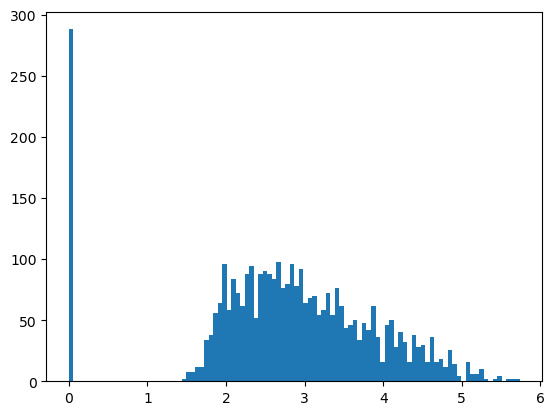

MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.0698307513767447, 'r_min': 0.8558646011013957, 'r_core': 1.0698307513767447, 'r_cut': 3.209492254130234, 'volume': 5.129013483808323}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.2614995530639361, 'r_min': 1.009199642451149, 'r_core': 1.2614995530639361, 'r_cut': 3.7844986591918084, 'volume': 8.409107651689514}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 0.8424167219772456, 'r_min': 0.6739333775817965, 'r_core': 0.8424167219772456, 'r_cut': 2.527250165931737, 'volume': 2.504203085605331}, 4: {'species_id': 4, 'original_symbol': 'Cl', 'symbol': 'Be', 'r_atom': 1.0512619443415534, 'r_min': 0.8410095554732427, 'r_core': 1.0512619443415534, 'r_cut': 3.15378583302466, 'volume': 4.866552793293221}, 5: {'species_id': 5, 'original_symbol': 'Cl', 'symbol': 'B', 

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  334.67500715799304  CURRENT:  346.69108222558486
32 -12.016075067591828 min dist:  1.242800820510437 ***** 30 30 1 1.242800820510437
ACCEPT BY CRITERION
Atoms(symbols='Cl10Li2', pbc=True, cell=[[7.91781774567004, 0.0, 0.0], [1.6009872739978723, 4.643459091078586, 0.0], [0.8972089550073811, 2.3199769250626976, 6.2532380404421515]], tags=...)
./configs//Cl10Li2.e.3.vasp
K= 1.1 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.0032569334851589, 'r_min': 0.8026055467881271, 'r_core': 1.0032569334851589, 'r_cut': 3.0097708004554766, 'volume': 4.229851481973347}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.8642160870987429, 'r_min': 0.6913728696789944, 'r_core': 0.8642160870987429, 'r_cut': 2.5926482612962287, 'volume': 2.703682239731612}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 1.23401655

RuntimeError: dictionary changed size during iteration

Exception ignored in: 'mliap_model_python_couple.MLIAPPY_compute_gradients'
Traceback (most recent call last):
  File "/home/d_perez/notebooks/entropy/entropy_utils.py", line 227, in __call__
    for module_name, module in sys.modules.items():
RuntimeError: dictionary changed size during iteration


CANDIDATE:  232.14646658504904  CURRENT:  242.81446148334868
42 -10.66799489829964 min dist:  1.2443604526324086 ***** 39 39 1 1.2443604526324086
ACCEPT BY CRITERION
Atoms(symbols='Cl3Li9', pbc=True, cell=[[6.997162617539648, 0.0, 0.0], [3.1044190760588135, 6.27387534953999, 0.0], [1.8390863066231353, -0.8718030421220138, 6.742008064915901]], tags=...)
./configs//Cl3Li9.e.3.vasp
K= 1.2100000000000002 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.1452770632228548, 'r_min': 0.9162216505782839, 'r_core': 1.1452770632228548, 'r_cut': 3.4358311896685647, 'volume': 6.292457609578477}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.099626866711477, 'r_min': 0.8797014933691817, 'r_core': 1.099626866711477, 'r_cut': 3.298880600134431, 'volume': 5.56960808016654}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  180.008813871593  CURRENT:  190.31479320231628
48 -10.30597933072329 min dist:  1.2478462798145953 ***** 44 44 1 1.2478462798145953
ACCEPT BY CRITERION
Atoms(symbols='Cl10Li2', pbc=True, cell=[[7.51013377323067, 0.0, 0.0], [1.741149340566135, 5.114385464036371, 0.0], [1.2991003765362363, 0.031693786379110404, 5.005321716243431]], tags=...)
./configs//Cl10Li2.e.5.vasp
K= 1.3310000000000004 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.1562227305387516, 'r_min': 0.9249781844310013, 'r_core': 1.1562227305387516, 'r_cut': 3.4686681916162545, 'volume': 6.474602616955941}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.1782304349513488, 'r_min': 0.9425843479610791, 'r_core': 1.1782304349513488, 'r_cut': 3.5346913048540465, 'volume': 6.85139994430561}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom

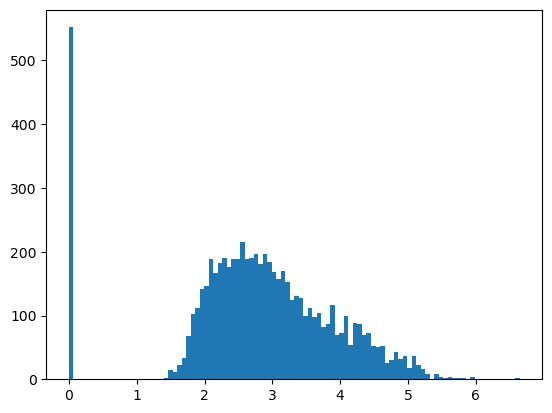

MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.9509322083249454, 'r_min': 0.7607457666599564, 'r_core': 0.9509322083249454, 'r_cut': 2.852796624974836, 'volume': 3.601946693496103}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.0474465443257328, 'r_min': 0.8379572354605863, 'r_core': 1.0474465443257328, 'r_cut': 3.1423396329771984, 'volume': 4.813757565682241}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 1.0103667843553743, 'r_min': 0.8082934274842994, 'r_core': 1.0103667843553743, 'r_cut': 3.031100353066123, 'volume': 4.32041823648028}, 4: {'species_id': 4, 'original_symbol': 'Cl', 'symbol': 'Be', 'r_atom': 0.9457182431926094, 'r_min': 0.7565745945540876, 'r_core': 0.9457182431926094, 'r_cut': 2.8371547295778283, 'volume': 3.543022494601968}, 5: {'species_id': 5, 'original_symbol': 'Cl', 'symbol': 'B'

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  85.87133574370584  CURRENT:  86.99392220958849
64 -1.122586465882648 min dist:  1.2466240500829644 ***** 59 59 1 1.2466240500829644
ACCEPT BY CRITERION
Atoms(symbols='Cl2Li10', pbc=True, cell=[[10.708422523713995, 0.0, 0.0], [3.2469343238222867, 5.71933566785482, 0.0], [1.3117538313663997, 3.167608392930419, 6.53483141729158]], tags=...)
./configs//Cl2Li10.e.3.vasp
K= 1.4641000000000006 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.067642036679945, 'r_min': 0.8541136293439561, 'r_core': 1.067642036679945, 'r_cut': 3.202926110039835, 'volume': 5.097598244845189}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.4115649339724292, 'r_min': 1.1292519471779434, 'r_core': 1.4115649339724292, 'r_cut': 4.234694801917287, 'volume': 11.781245136478603}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 1

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  81.75521475495627  CURRENT:  82.70801871144747
68 -0.952803956491195 min dist:  1.2460839187296373 ***** 63 63 1 1.2460839187296373
ACCEPT BY CRITERION
Atoms(symbols='Cl7Li5', pbc=True, cell=[[8.882516126493648, 0.0, 0.0], [2.3725390328490654, 4.377246727390212, 0.0], [0.2370738651672449, 1.7259866537092288, 5.836999685143465]], tags=...)
./configs//Cl7Li5.e.6.vasp
K= 1.4641000000000006 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.9659117013434391, 'r_min': 0.7727293610747513, 'r_core': 0.9659117013434391, 'r_cut': 2.897735104030317, 'volume': 3.774860362794126}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.9387188817788128, 'r_min': 0.7509751054230502, 'r_core': 0.9387188817788128, 'r_cut': 2.8161566453364384, 'volume': 3.464936419864321}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom':

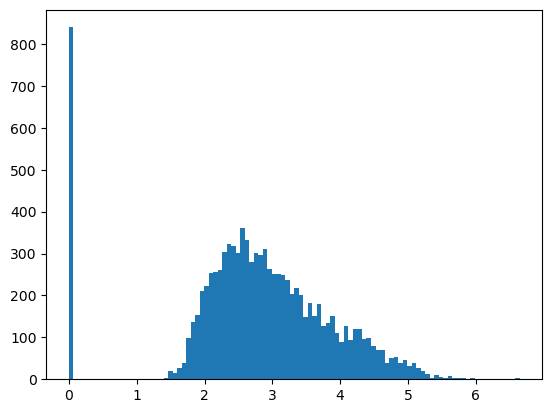

MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.0900795296058305, 'r_min': 0.8720636236846645, 'r_core': 1.0900795296058305, 'r_cut': 3.2702385888174916, 'volume': 5.425792262111397}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.670506697479339, 'r_min': 1.3364053579834714, 'r_core': 1.670506697479339, 'r_cut': 5.011520092438017, 'volume': 19.526898679768223}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 1.6463383153860514, 'r_min': 1.3170706523088411, 'r_core': 1.6463383153860514, 'r_cut': 4.939014946158154, 'volume': 18.69157365104182}, 4: {'species_id': 4, 'original_symbol': 'Cl', 'symbol': 'Be', 'r_atom': 1.0550216473524148, 'r_min': 0.8440173178819319, 'r_core': 1.0550216473524148, 'r_cut': 3.1650649420572443, 'volume': 4.918953550559323}, 5: {'species_id': 5, 'original_symbol': 'Cl', 'symbol': 'B'

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  77.29651313387676  CURRENT:  77.85418771055564
76 -0.5576745766788775 min dist:  1.2460376565028681 ***** 70 70 1 1.2460376565028681
ACCEPT BY CRITERION
Atoms(symbols='Cl9Li3', pbc=True, cell=[[8.251999601903078, 0.0, 0.0], [1.096418269243691, 6.085515030966869, 0.0], [1.9469493794259043, 0.29634158978253655, 5.216758801138496]], tags=...)
./configs//Cl9Li3.e.3.vasp
K= 1.6105100000000008 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.2661784569617998, 'r_min': 1.0129427655694399, 'r_core': 1.2661784569617998, 'r_cut': 3.798535370885399, 'volume': 8.503023307238731}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.0784466484807131, 'r_min': 0.8627573187845705, 'r_core': 1.0784466484807131, 'r_cut': 3.2353399454421394, 'volume': 5.253933900502914}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom'

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  77.43786108393888  CURRENT:  77.21913485020484
78 0.21872623373404565 min dist:  1.2527845476122208 ***** 72 72 1 1.2527845476122208
ACCEPT BY CRITERION
Atoms(symbols='Cl10Li2', pbc=True, cell=[[8.838669536811352, 0.0, 0.0], [1.999667369894084, 4.8752471861404185, 0.0], [2.667165474337669, -0.3081947518117666, 4.728343804655101]], tags=...)
./configs//Cl10Li2.e.6.vasp
K= 1.6105100000000008 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.637637854157222, 'r_min': 1.3101102833257778, 'r_core': 1.637637854157222, 'r_cut': 4.912913562471666, 'volume': 18.396796946876496}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.5793149285777488, 'r_min': 1.263451942862199, 'r_core': 1.5793149285777488, 'r_cut': 4.737944785733246, 'volume': 16.500413625644523}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom'

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  76.59231250840898  CURRENT:  77.43786108393888
79 -0.8455485755299037 min dist:  1.244647252303304 ***** 73 73 1 1.244647252303304
ACCEPT BY CRITERION
Atoms(symbols='Cl8Li4', pbc=True, cell=[[10.374635624268432, 0.0, 0.0], [2.0722767412832224, 4.030431125287352, 0.0], [2.5776052974329438, 0.24051087777915983, 4.67077026899794]], tags=...)
./configs//Cl8Li4.e.7.vasp
K= 1.6105100000000008 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.0972782231275775, 'r_min': 0.877822578502062, 'r_core': 1.0972782231275775, 'r_cut': 3.2918346693827325, 'volume': 5.533996623051808}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.8865768631957451, 'r_min': 0.7092614905565962, 'r_core': 0.8865768631957451, 'r_cut': 2.6597305895872356, 'volume': 2.91902483229367}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  73.25142004302698  CURRENT:  73.22590615030177
89 0.02551389272521476 min dist:  1.2465576739773667 ***** 82 82 1 1.2465576739773667
ACCEPT BY CRITERION
Atoms(symbols='Cl2Li10', pbc=True, cell=[[12.526912172537806, 0.0, 0.0], [1.029993631982891, 5.9591528520833315, 0.0], [1.547925603721783, 1.5385090403037802, 6.092815383749088]], tags=...)
./configs//Cl2Li10.e.5.vasp
K= 1.771561000000001 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.1109972898724219, 'r_min': 0.8887978318979375, 'r_core': 1.1109972898724219, 'r_cut': 3.3329918696172656, 'volume': 5.744174278145788}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.015171668400595, 'r_min': 0.812137334720476, 'r_core': 1.015171668400595, 'r_cut': 3.0455150052017848, 'volume': 4.382350162052512}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom':

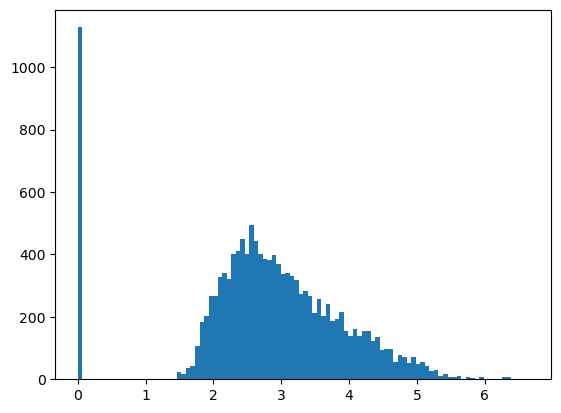

MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.692082529722494, 'r_min': 1.3536660237779952, 'r_core': 1.692082529722494, 'r_cut': 5.076247589167481, 'volume': 20.293326082416286}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.5778788995693604, 'r_min': 1.2623031196554884, 'r_core': 1.5778788995693604, 'r_cut': 4.733636698708081, 'volume': 16.455444379637722}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 1.009590586240047, 'r_min': 0.8076724689920376, 'r_core': 1.009590586240047, 'r_cut': 3.028771758720141, 'volume': 4.310468607500684}, 4: {'species_id': 4, 'original_symbol': 'Li', 'symbol': 'Be', 'r_atom': 1.5257555900158473, 'r_min': 1.2206044720126779, 'r_core': 1.5257555900158473, 'r_cut': 4.577266770047542, 'volume': 14.877964518782656}, 5: {'species_id': 5, 'original_symbol': 'Li', 'symbol': 'B', 

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  66.34785109124248  CURRENT:  66.61413934013419
105 -0.266288248891712 min dist:  1.2465059207845843 ***** 98 98 1 1.2465059207845843
ACCEPT BY CRITERION
Atoms(symbols='Cl4Li8', pbc=True, cell=[[7.977780181544109, 0.0, 0.0], [1.4671920326571823, 4.822938836835186, 0.0], [2.9197115678938337, 0.9709875319592737, 7.027829323558041]], tags=...)
./configs//Cl4Li8.e.6.vasp
K= 2.1435888100000016 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.3241034852829983, 'r_min': 1.0592827882263987, 'r_core': 1.3241034852829983, 'r_cut': 3.972310455848995, 'volume': 9.72421148469555}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.182157617547021, 'r_min': 0.9457260940376169, 'r_core': 1.182157617547021, 'r_cut': 3.546472852641063, 'volume': 6.920138148720587}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 1.

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  66.2178307114842  CURRENT:  66.299963572961
107 -0.08213286147680776 min dist:  1.2455866889673421 ***** 100 100 1 1.2455866889673421
ACCEPT BY CRITERION
Atoms(symbols='Cl11Li', pbc=True, cell=[[7.596127482023712, 0.0, 0.0], [0.4490741548379187, 4.937060046525428, 0.0], [0.9841517812114376, 1.579351136097662, 5.062273570044998]], tags=...)
./configs//Cl11Li.e.7.vasp
K= 2.1435888100000016 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.2231661194190468, 'r_min': 0.9785328955352375, 'r_core': 1.2231661194190468, 'r_cut': 3.6694983582571403, 'volume': 7.665578551311531}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.0800744793911266, 'r_min': 0.8640595835129012, 'r_core': 1.0800744793911266, 'r_cut': 3.2402234381733797, 'volume': 5.277761037059351}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom

...

CANDIDATE:  64.44161532076593  CURRENT:  65.00594738726406
115 -0.5643320664981246 min dist:  1.2421830096166768 ***** 108 108 1 1.2421830096166768
ACCEPT BY CRITERION
Atoms(symbols='Cl6Li6', pbc=True, cell=[[12.274177213121947, 0.0, 0.0], [1.609284687985641, 4.688498995282687, 0.0], [1.8342915799729962, 1.1910954115820624, 5.234609118384311]], tags=...)
./configs//Cl6Li6.e.9.vasp
K= 2.1435888100000016 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.8619449964540645, 'r_min': 0.6895559971632517, 'r_core': 0.8619449964540645, 'r_cut': 2.5858349893621937, 'volume': 2.6824230242491045}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.8226111404478834, 'r_min': 0.6580889123583068, 'r_core': 0.8226111404478834, 'r_cut': 2.4678334213436504, 'volume': 2.331698372727172}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  64.32436791332597  CURRENT:  64.44161532076593
116 -0.11724740743996165 min dist:  1.244148461880262 ***** 109 109 1 1.244148461880262
ACCEPT BY CRITERION
Atoms(symbols='Cl4Li8', pbc=True, cell=[[8.85875388570614, 0.0, 0.0], [2.382470503855152, 4.706772088250316, 0.0], [3.229543552554235, 1.2298116495448048, 6.286786087945871]], tags=...)
./configs//Cl4Li8.e.8.vasp
K= 2.357947691000002 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.9738436955723193, 'r_min': 0.7790749564578555, 'r_core': 0.9738436955723193, 'r_cut': 2.921531086716958, 'volume': 3.8686227423583235}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.0151363267159492, 'r_min': 0.8121090613727594, 'r_core': 1.0151363267159492, 'r_cut': 3.0454089801478474, 'volume': 4.381892483069495}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom':

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  62.87012634659623  CURRENT:  63.72825075710632
121 -0.8581244105100936 min dist:  1.2228660465161703 ***** 114 114 1 1.2228660465161703
ACCEPT BY CRITERION
Atoms(symbols='Cl6Li6', pbc=True, cell=[[8.054960847235051, 0.0, 0.0], [1.2467920299497042, 6.138369657364126, 0.0], [0.4634259517605994, 1.5731088267304825, 4.306964849322685]], tags=...)
./configs//Cl6Li6.e.10.vasp
K= 2.357947691000002 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.08951488834088, 'r_min': 0.871611910672704, 'r_core': 1.08951488834088, 'r_cut': 3.26854466502264, 'volume': 5.417365245105634}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.1163444973935706, 'r_min': 0.8930755979148565, 'r_core': 1.1163444973935706, 'r_cut': 3.3490334921807117, 'volume': 5.8275138904963715}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 

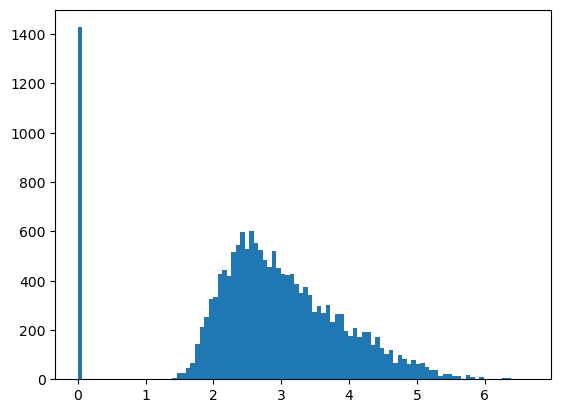

MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.1473674971934569, 'r_min': 0.9178939977547655, 'r_core': 1.1473674971934569, 'r_cut': 3.4421024915803704, 'volume': 6.32697674468718}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.2301855185557866, 'r_min': 0.9841484148446293, 'r_core': 1.2301855185557866, 'r_cut': 3.69055655566736, 'volume': 7.7983090101064505}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 0.9660577797106632, 'r_min': 0.7728462237685306, 'r_core': 0.9660577797106632, 'r_cut': 2.8981733391319895, 'volume': 3.77657327972791}, 4: {'species_id': 4, 'original_symbol': 'Li', 'symbol': 'Be', 'r_atom': 1.3366759640770791, 'r_min': 1.0693407712616634, 'r_core': 1.3366759640770791, 'r_cut': 4.010027892231237, 'volume': 10.003846641558706}, 5: {'species_id': 5, 'original_symbol': 'Li', 'symbol': 'B'

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  61.84793346943929  CURRENT:  62.0311000968082
132 -0.18316662736891232 min dist:  1.2439441556409347 ***** 125 125 1 1.2439441556409347
ACCEPT BY CRITERION
Atoms(symbols='Cl3Li9', pbc=True, cell=[[11.146967480199333, 0.0, 0.0], [0.16028587946278358, 4.461126922236737, 0.0], [3.085044000873014, 0.4288793745700267, 6.981794126348911]], tags=...)
./configs//Cl3Li9.e.11.vasp
K= 2.5937424601000023 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.1743540322219135, 'r_min': 0.9394832257775309, 'r_core': 1.1743540322219135, 'r_cut': 3.5230620966657407, 'volume': 6.783998437282259}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.1758893593732471, 'r_min': 0.9407114874985978, 'r_core': 1.1758893593732471, 'r_cut': 3.527668078119741, 'volume': 6.810641033637476}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  60.22682540746688  CURRENT:  60.63371413680336
145 -0.40688872933647957 min dist:  1.2395539650103238 ***** 137 137 1 1.2395539650103238
ACCEPT BY CRITERION
Atoms(symbols='Cl8Li4', pbc=True, cell=[[6.335306759919765, 0.0, 0.0], [1.6101735419459131, 6.19596117323657, 0.0], [1.1363199969336812, 0.24612439733571248, 5.495876794082522]], tags=...)
./configs//Cl8Li4.e.9.vasp
K= 2.853116706110003 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.6133643656765073, 'r_min': 1.2906914925412059, 'r_core': 1.6133643656765073, 'r_cut': 4.840093097029522, 'volume': 17.590816194027973}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.3582644081074458, 'r_min': 1.0866115264859566, 'r_core': 1.3582644081074458, 'r_cut': 4.074793224322337, 'volume': 10.496428967884691}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_a

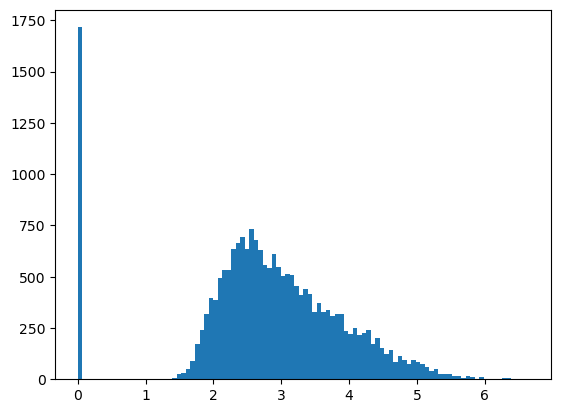

MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.9275018579578702, 'r_min': 0.7420014863662963, 'r_core': 0.9275018579578702, 'r_cut': 2.7825055738736104, 'volume': 3.3422041495898993}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.2224706800018557, 'r_min': 0.9779765440014846, 'r_core': 1.2224706800018557, 'r_cut': 3.667412040005567, 'volume': 7.652511033274497}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 1.1227288029381708, 'r_min': 0.8981830423505367, 'r_core': 1.1227288029381708, 'r_cut': 3.3681864088145126, 'volume': 5.92806834996193}, 4: {'species_id': 4, 'original_symbol': 'Cl', 'symbol': 'Be', 'r_atom': 0.7780288036566554, 'r_min': 0.6224230429253244, 'r_core': 0.7780288036566554, 'r_cut': 2.334086410969966, 'volume': 1.9727662782133064}, 5: {'species_id': 5, 'original_symbol': 'Li', 'symbol': '

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  58.985966040285355  CURRENT:  59.63723724874701
157 -0.6512712084616581 min dist:  1.2381914022945255 ***** 149 149 1 1.2381914022945255
ACCEPT BY CRITERION
Atoms(symbols='Cl6Li6', pbc=True, cell=[[7.870828445308886, 0.0, 0.0], [1.5438277828302105, 7.72419053850564, 0.0], [0.5122463928385361, 0.7353326816551675, 3.5162556908179132]], tags=...)
./configs//Cl6Li6.e.12.vasp
K= 3.1384283767210035 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.1720105878300702, 'r_min': 0.9376084702640561, 'r_core': 1.1720105878300702, 'r_cut': 3.5160317634902105, 'volume': 6.743466657673124}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.8588676367145621, 'r_min': 0.6870941093716497, 'r_core': 0.8588676367145621, 'r_cut': 2.5766029101436865, 'volume': 2.65379471006334}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  59.10251873291071  CURRENT:  58.90258459750473
159 0.19993413540598226 min dist:  1.2460566296974642 ***** 151 151 1 1.2460566296974642
ACCEPT BY CRITERION
Atoms(symbols='ClLi11', pbc=True, cell=[[6.914422967043122, 0.0, 0.0], [2.7813830699194093, 5.920118479036683, 0.0], [0.03888769147496967, 1.052771345248751, 7.4622285804244335]], tags=...)
./configs//ClLi11.e.10.vasp
K= 3.1384283767210035 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.006689813282462, 'r_min': 0.8053518506259696, 'r_core': 1.006689813282462, 'r_cut': 3.020069439847386, 'volume': 4.27342052227611}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.2544865223659132, 'r_min': 1.0035892178927306, 'r_core': 1.2544865223659132, 'r_cut': 3.7634595670977395, 'volume': 8.269640091417136}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_ato

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  57.939211845145444  CURRENT:  58.50824531650997
166 -0.5690334713645271 min dist:  1.2417866318220614 ***** 157 157 1 1.2417866318220614
ACCEPT BY CRITERION
Atoms(symbols='Cl8Li4', pbc=True, cell=[[8.851562190284927, 0.0, 0.0], [1.1968164487476118, 4.198679574540619, 0.0], [2.4133402660449703, 0.5017699754251627, 7.734125643958917]], tags=...)
./configs//Cl8Li4.e.13.vasp
K= 3.4522712143931042 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.4105836707287258, 'r_min': 1.1284669365829807, 'r_core': 1.4105836707287258, 'r_cut': 4.231751012186177, 'volume': 11.756692667078644}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.0429393136832956, 'r_min': 0.8343514509466365, 'r_core': 1.0429393136832956, 'r_cut': 3.1288179410498866, 'volume': 4.751882845894448}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  57.72310622390359  CURRENT:  57.915603123945154
173 -0.1924969000415615 min dist:  1.243673183118508 ***** 163 163 1 1.243673183118508
ACCEPT BY CRITERION
Atoms(symbols='Cl7Li5', pbc=True, cell=[[6.264497438389841, 0.0, 0.0], [1.6487300074957358, 5.041755668560338, 0.0], [2.769672831298099, 1.4543585371248036, 8.172784898014463]], tags=...)
./configs//Cl7Li5.e.10.vasp
K= 3.4522712143931042 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.5695035458126134, 'r_min': 1.2556028366500909, 'r_core': 1.5695035458126134, 'r_cut': 4.70851063743784, 'volume': 16.194797161590614}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 0.9673293922363589, 'r_min': 0.7738635137890872, 'r_core': 0.9673293922363589, 'r_cut': 2.901988176709077, 'volume': 3.7915061192502235}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_ato

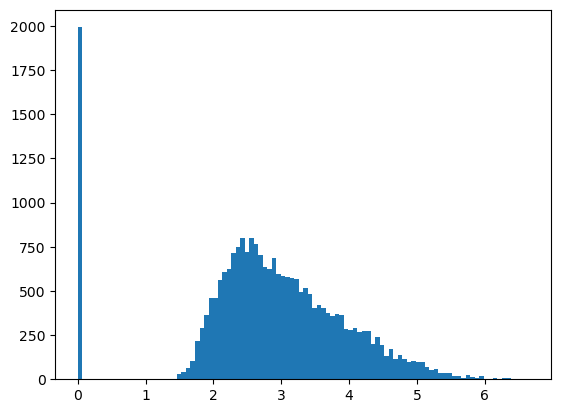

MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.7562345545193849, 'r_min': 0.6049876436155079, 'r_core': 0.7562345545193849, 'r_cut': 2.2687036635581546, 'volume': 1.8115826897668699}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.9998128671730765, 'r_min': 0.7998502937384613, 'r_core': 0.9998128671730765, 'r_cut': 2.9994386015192296, 'volume': 4.186439064359606}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 1.6127874777352784, 'r_min': 1.2902299821882228, 'r_core': 1.6127874777352784, 'r_cut': 4.838362433205836, 'volume': 17.571953186125164}, 4: {'species_id': 4, 'original_symbol': 'Li', 'symbol': 'Be', 'r_atom': 1.3048761588638127, 'r_min': 1.0439009270910502, 'r_core': 1.3048761588638127, 'r_cut': 3.914628476591438, 'volume': 9.30671678899835}, 5: {'species_id': 5, 'original_symbol': 'Li', 'symbol': '

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  56.982514771620416  CURRENT:  57.14401283853818
183 -0.16149806691776547 min dist:  1.2430979878067239 ***** 173 173 1 1.2430979878067239
ACCEPT BY CRITERION
Atoms(symbols='Cl9Li3', pbc=True, cell=[[7.100508271880852, 0.0, 0.0], [2.014956540283118, 4.914837689957344, 0.0], [2.9854152916892542, -0.13517271326896116, 5.587320425387704]], tags=...)
./configs//Cl9Li3.e.12.vasp
K= 3.797498335832415 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.404950009347182, 'r_min': 1.1239600074777456, 'r_core': 1.404950009347182, 'r_cut': 4.214850028041546, 'volume': 11.616391060028885}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.2977286987863874, 'r_min': 1.03818295902911, 'r_core': 1.2977286987863874, 'r_cut': 3.8931860963591625, 'volume': 9.154620304917852}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_at

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  56.89677857759829  CURRENT:  56.962399632310095
188 -0.06562105471180502 min dist:  1.243168436533528 ***** 177 177 1 1.243168436533528
ACCEPT BY CRITERION
Atoms(symbols='Cl9Li3', pbc=True, cell=[[7.161661126138025, 0.0, 0.0], [0.1980928576093282, 6.144177462271356, 0.0], [2.6519798478635797, 0.9357220024144206, 8.052695746688686]], tags=...)
./configs//Cl9Li3.e.14.vasp
K= 4.177248169415656 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.8997144822137498, 'r_min': 0.7197715857709999, 'r_core': 0.8997144822137498, 'r_cut': 2.6991434466412496, 'volume': 3.0507227640874572}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.788418517834056, 'r_min': 0.6307348142672449, 'r_core': 0.788418517834056, 'r_cut': 2.365255553502168, 'volume': 2.052858700826954}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_ato

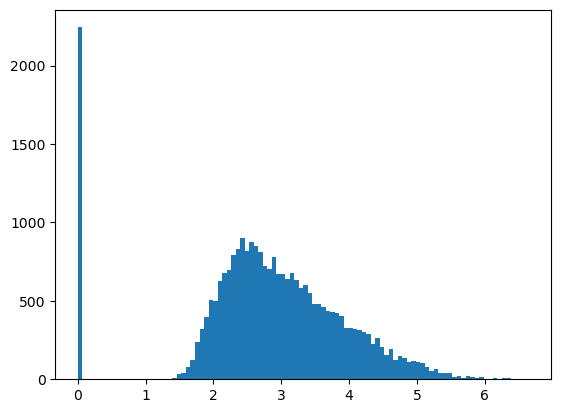

MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.0068933866869978, 'r_min': 0.8055147093495982, 'r_core': 1.0068933866869978, 'r_cut': 3.0206801600609934, 'volume': 4.276013567386551}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.027565329622525, 'r_min': 0.82205226369802, 'r_core': 1.027565329622525, 'r_cut': 3.0826959888675747, 'volume': 4.544822613004086}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 1.2821719369060807, 'r_min': 1.0257375495248646, 'r_core': 1.2821719369060807, 'r_cut': 3.846515810718242, 'volume': 8.829323123942663}, 4: {'species_id': 4, 'original_symbol': 'Li', 'symbol': 'Be', 'r_atom': 1.1392859907875736, 'r_min': 0.9114287926300589, 'r_core': 1.1392859907875736, 'r_cut': 3.4178579723627207, 'volume': 6.1942236302899065}, 5: {'species_id': 5, 'original_symbol': 'Li', 'symbol': 'B',

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  55.87959493694474  CURRENT:  55.81821381934187
209 0.06138111760287046 min dist:  1.2452204646047016 ***** 194 194 1 1.2452204646047016
ACCEPT BY CRITERION
Atoms(symbols='Cl2Li10', pbc=True, cell=[[9.285174319761271, 0.0, 0.0], [1.5387245594754075, 6.07360484144139, 0.0], [0.6906890011253489, 1.2992329424285614, 6.930418667684836]], tags=...)
./configs//Cl2Li10.e.15.vasp
K= 4.594972986357222 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.2056200002936108, 'r_min': 0.9644960002348887, 'r_core': 1.2056200002936108, 'r_cut': 3.6168600008808323, 'volume': 7.340403628401336}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.3720531241510867, 'r_min': 1.0976424993208693, 'r_core': 1.3720531241510867, 'r_cut': 4.11615937245326, 'volume': 10.819355485054622}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_a

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  54.37272740590171  CURRENT:  54.673760031909936
220 -0.30103262600822234 min dist:  1.271252906591503 ***** 204 204 1 1.271252906591503
ACCEPT BY CRITERION
Atoms(symbols='Cl2Li10', pbc=True, cell=[[10.335816466935617, 0.0, 0.0], [2.6944819656369385, 4.921146257743194, 0.0], [1.1817650307439058, 0.8663218322727364, 5.799339614683828]], tags=...)
./configs//Cl2Li10.e.18.vasp
K= 5.054470284992944 0 0
MendeleevUniformRadiusSampler  ('Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.398538723385075, 'r_min': 1.1188309787080601, 'r_core': 1.398538723385075, 'r_cut': 4.195616170155225, 'volume': 11.4580865062535}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.223011608371334, 'r_min': 0.9784092866970673, 'r_core': 1.223011608371334, 'r_cut': 3.669034825114002, 'volume': 7.662673957377958}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom'

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  53.86194950721654  CURRENT:  53.853437482556274
223 0.008512024660269901 min dist:  1.2422284437842623 ***** 207 207 1 1.2422284437842623
ACCEPT BY CRITERION
Atoms(symbols='ClLi11', pbc=True, cell=[[7.983736330200561, 0.0, 0.0], [1.3043823792790719, 8.567499897549466, 0.0], [1.0238560191246175, 2.014766814994073, 5.313865760692482]], tags=...)
./configs//ClLi11.e.14.vasp
K= 5.054470284992944 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.302000601505752, 'r_min': 1.0416004812046016, 'r_core': 1.302000601505752, 'r_cut': 3.9060018045172558, 'volume': 9.245324604849081}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.6035251925333522, 'r_min': 1.282820154026682, 'r_core': 1.6035251925333522, 'r_cut': 4.810575577600057, 'volume': 17.270939843816134}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_ato

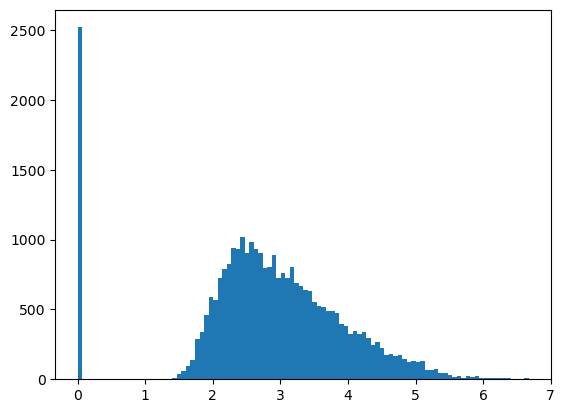

MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.8777233972472375, 'r_min': 0.7021787177977901, 'r_core': 0.8777233972472375, 'r_cut': 2.6331701917417125, 'volume': 2.832445977728537}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.7655879436880252, 'r_min': 0.6124703549504202, 'r_core': 0.7655879436880252, 'r_cut': 2.2967638310640757, 'volume': 1.879636484425217}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 0.9691846693224876, 'r_min': 0.7753477354579901, 'r_core': 0.9691846693224876, 'r_cut': 2.907554007967463, 'volume': 3.8133635995731465}, 4: {'species_id': 4, 'original_symbol': 'Cl', 'symbol': 'Be', 'r_atom': 0.740984339536839, 'r_min': 0.5927874716294712, 'r_core': 0.740984339536839, 'r_cut': 2.222953018610517, 'volume': 1.704180915583036}, 5: {'species_id': 5, 'original_symbol': 'Cl', 'symbol': 'B'

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  53.935072470333935  CURRENT:  54.02456627044493
229 -0.0894938001109935 min dist:  1.242706306270091 ***** 212 212 1 1.242706306270091
ACCEPT BY CRITERION
Atoms(symbols='Cl11Li', pbc=True, cell=[[10.014507866840567, 0.0, 0.0], [1.2951428376157224, 3.557032477915703, 0.0], [0.30620935340312366, -0.07793208729656573, 5.190600566623888]], tags=...)
./configs//Cl11Li.e.17.vasp
K= 5.559917313492239 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.3773310307208804, 'r_min': 1.1018648245767044, 'r_core': 1.3773310307208804, 'r_cut': 4.1319930921626415, 'volume': 10.944693541217418}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.0714617455045206, 'r_min': 0.8571693964036164, 'r_core': 1.0714617455045206, 'r_cut': 3.2143852365135617, 'volume': 5.15250734208192}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', '

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  53.748151043217355  CURRENT:  53.68172590980115
235 0.06642513341620315 min dist:  1.2413815901504774 ***** 218 218 1 1.2413815901504774
ACCEPT BY CRITERION
Atoms(symbols='Cl7Li5', pbc=True, cell=[[5.909540439400193, 0.0, 0.0], [1.965158663726806, 6.781760181976689, 0.0], [1.1217968446218205, 1.7998985237441232, 5.27863692212829]], tags=...)
./configs//Cl7Li5.e.15.vasp
K= 5.559917313492239 0 0
MendeleevUniformRadiusSampler  ('Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.6417514902937342, 'r_min': 1.3134011922349875, 'r_core': 1.6417514902937342, 'r_cut': 4.925254470881203, 'volume': 18.535780028622458}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.2508964301493897, 'r_min': 1.0007171441195117, 'r_core': 1.2508964301493897, 'r_cut': 3.752689290448169, 'volume': 8.198844859279752}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_ato

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  53.85593248831005  CURRENT:  53.748151043217355
236 0.10778144509269794 min dist:  1.2432436332004777 ***** 219 219 1 1.2432436332004777
ACCEPT BY CRITERION
Atoms(symbols='Cl11Li', pbc=True, cell=[[6.249708495180323, 0.0, 0.0], [0.9792501751607334, 5.210433314756387, 0.0], [0.17965630657662945, 1.4635003458050544, 5.650743679475626]], tags=...)
./configs//Cl11Li.e.18.vasp
K= 6.115909044841463 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.0990044369463194, 'r_min': 0.8792035495570556, 'r_core': 1.0990044369463194, 'r_cut': 3.2970133108389583, 'volume': 5.560155615747281}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.0315015451450005, 'r_min': 0.8252012361160004, 'r_core': 1.0315015451450005, 'r_cut': 3.094504635435001, 'volume': 4.597251444108382}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_

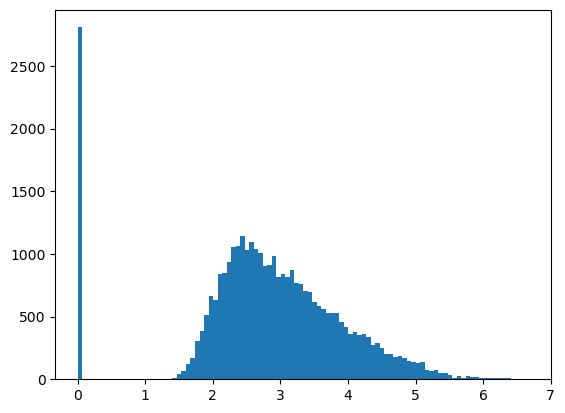

MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.2807621674117404, 'r_min': 1.0246097339293925, 'r_core': 1.2807621674117404, 'r_cut': 3.842286502235221, 'volume': 8.800231169046658}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.8485137144038327, 'r_min': 0.6788109715230662, 'r_core': 0.8485137144038327, 'r_cut': 2.5455411432114983, 'volume': 2.558970078186541}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 1.0116111397577203, 'r_min': 0.8092889118061763, 'r_core': 1.0116111397577203, 'r_cut': 3.034833419273161, 'volume': 4.336400827429555}, 4: {'species_id': 4, 'original_symbol': 'Cl', 'symbol': 'Be', 'r_atom': 0.8844755617738543, 'r_min': 0.7075804494190835, 'r_core': 0.8844755617738543, 'r_cut': 2.653426685321563, 'volume': 2.8983185912793457}, 5: {'species_id': 5, 'original_symbol': 'Cl', 'symbol': 'B

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  51.94553654357617  CURRENT:  52.16679069710497
260 -0.22125415352880395 min dist:  1.2280944741735198 ***** 243 243 1 1.2280944741735198
ACCEPT BY CRITERION
Atoms(symbols='Cl3Li9', pbc=True, cell=[[7.547789139409999, 0.0, 0.0], [3.099119086890968, 6.604780297674855, 0.0], [2.0840183304733895, -0.14478034991697908, 5.978760046595117]], tags=...)
./configs//Cl3Li9.e.17.vasp
K= 7.400249944258172 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.3507262531120339, 'r_min': 1.0805810024896272, 'r_core': 1.3507262531120339, 'r_cut': 4.052178759336101, 'volume': 10.322636451183337}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.196797031153375, 'r_min': 0.9574376249227001, 'r_core': 1.196797031153375, 'r_cut': 3.5903910934601253, 'volume': 7.1804244796739916}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  51.38067327379724  CURRENT:  51.267076829027914
266 0.11359644476932829 min dist:  1.2426535776787198 ***** 249 249 1 1.2426535776787198
ACCEPT BY CRITERION
Atoms(symbols='Cl11Li', pbc=True, cell=[[5.780283146936618, 0.0, 0.0], [3.8755181127123564, 6.773733544768486, 0.0], [1.3148746827471904, 0.8569689725544899, 3.9709711026900343]], tags=...)
./configs//Cl11Li.e.20.vasp
K= 7.400249944258172 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.9834503003144047, 'r_min': 0.7867602402515238, 'r_core': 0.9834503003144047, 'r_cut': 2.950350900943214, 'volume': 3.9842433932802}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.8752082806030761, 'r_min': 0.7001666244824609, 'r_core': 0.8752082806030761, 'r_cut': 2.6256248418092283, 'volume': 2.808166559245204}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_at

...

CANDIDATE:  51.16848911587305  CURRENT:  51.14586279860289
284 0.02262631727015929 min dist:  1.241629217084097 ***** 265 265 1 1.241629217084097
ACCEPT BY CRITERION
Atoms(symbols='Cl5Li7', pbc=True, cell=[[10.450835680040088, 0.0, 0.0], [2.5836182292251846, 5.528603739603766, 0.0], [0.4279633005194369, 2.056766932740264, 4.865303557654393]], tags=...)
./configs//Cl5Li7.e.30.vasp
K= 8.954302432552389 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.9716269990106221, 'r_min': 0.7773015992084977, 'r_core': 0.9716269990106221, 'r_cut': 2.914880997031866, 'volume': 3.842265152562875}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.8086441696690795, 'r_min': 0.6469153357352636, 'r_core': 0.8086441696690795, 'r_cut': 2.4259325090072386, 'volume': 2.214935011987445}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  51.30033831538469  CURRENT:  51.32894710626493
287 -0.02860879088023438 min dist:  1.2377055416310911 ***** 268 268 1 1.2377055416310911
ACCEPT BY CRITERION
Atoms(symbols='Li12', pbc=True, cell=[[6.496542844345388, 0.0, 0.0], [2.700787139152036, 5.07514952749523, 0.0], [0.2814297820784328, 0.3755755779920005, 7.356783289104819]], tags=...)
./configs//Li12.e.20.vasp
K= 8.954302432552389 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 0.9429476086976452, 'r_min': 0.7543580869581161, 'r_core': 0.9429476086976452, 'r_cut': 2.8288428260929352, 'volume': 3.511974062245529}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.6205471108607443, 'r_min': 1.2964376886885955, 'r_core': 1.6205471108607443, 'r_cut': 4.8616413325822325, 'volume': 17.826808205303458}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom'

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  51.52224342703965  CURRENT:  51.477859103152326
295 0.044384323887321386 min dist:  1.242504095452266 ***** 276 276 1 1.242504095452266
ACCEPT BY CRITERION
Atoms(symbols='Cl12', pbc=True, cell=[[7.790211271224411, 0.0, 0.0], [3.1910203599458478, 5.580721581324894, 0.0], [0.30716623454967856, 0.5692681700805245, 3.500214039366601]], tags=...)
./configs//Cl12.e.19.vasp
K= 9.849732675807628 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.2078461533758413, 'r_min': 0.9662769227006731, 'r_core': 1.2078461533758413, 'r_cut': 3.623538460127524, 'volume': 7.381140478659731}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.9229314778871702, 'r_min': 0.7383451823097362, 'r_core': 0.9229314778871702, 'r_cut': 2.768794433661511, 'volume': 3.2930398382151957}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom'

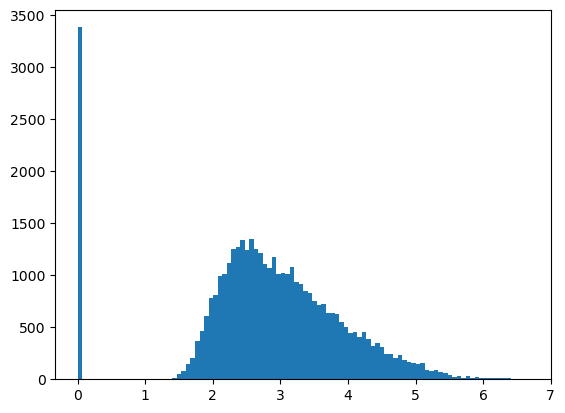

MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.1531828291993085, 'r_min': 0.9225462633594468, 'r_core': 1.1531828291993085, 'r_cut': 3.4595484875979254, 'volume': 6.42366835397647}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.7408330025971556, 'r_min': 0.5926664020777245, 'r_core': 0.7408330025971556, 'r_cut': 2.2224990077914666, 'volume': 1.7031369548396293}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 1.0930960310042421, 'r_min': 0.8744768248033937, 'r_core': 1.0930960310042421, 'r_cut': 3.2792880930127266, 'volume': 5.470960276804384}, 4: {'species_id': 4, 'original_symbol': 'Cl', 'symbol': 'Be', 'r_atom': 1.2668134792444876, 'r_min': 1.0134507833955901, 'r_core': 1.2668134792444876, 'r_cut': 3.800440437733463, 'volume': 8.515823203828642}, 5: {'species_id': 5, 'original_symbol': 'Cl', 'symbol': '

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  51.0006969227915  CURRENT:  50.9533574699784
305 0.04733945281309815 min dist:  1.2537748713944261 ***** 286 286 1 1.2537748713944261
ACCEPT BY CRITERION
Atoms(symbols='Cl10Li2', pbc=True, cell=[[5.58791942103667, 0.0, 0.0], [1.7209993117480187, 5.447378368019717, 0.0], [2.869125572293229, 1.329398480859346, 5.263339596195048]], tags=...)
./configs//Cl10Li2.e.18.vasp
K= 10.834705943388391 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.0507896609667977, 'r_min': 0.8406317287734382, 'r_core': 1.0507896609667977, 'r_cut': 3.152368982900393, 'volume': 4.859996788153646}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.5673829112044293, 'r_min': 1.2539063289635435, 'r_core': 1.5673829112044293, 'r_cut': 4.702148733613288, 'volume': 16.129241020387177}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  51.08307798907068  CURRENT:  51.039160776658136
308 0.04391721241254487 min dist:  1.2450791687681608 ***** 289 289 1 1.2450791687681608
ACCEPT BY CRITERION
Atoms(symbols='Cl12', pbc=True, cell=[[5.104444734310882, 0.0, 0.0], [2.6909526347282906, 6.3329698916765045, 0.0], [0.6792278662542691, 2.0125072536687596, 4.2416050857944265]], tags=...)
./configs//Cl12.e.21.vasp
K= 10.834705943388391 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.1871359938748391, 'r_min': 0.9497087950998714, 'r_core': 1.1871359938748391, 'r_cut': 3.5614079816245177, 'volume': 7.007934405808802}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.7746788044373473, 'r_min': 0.6197430435498779, 'r_core': 0.7746788044373473, 'r_cut': 2.324036413312042, 'volume': 1.9473931149232122}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_a

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  50.554550938889754  CURRENT:  50.653330196980825
313 -0.09877925809107069 min dist:  1.2315770296657944 ***** 294 294 1 1.2315770296657944
ACCEPT BY CRITERION
Atoms(symbols='Cl10Li2', pbc=True, cell=[[6.493951996143221, 0.0, 0.0], [0.26400891036624075, 6.7681225099034314, 0.0], [2.4958641658383978, 2.7950262712992244, 4.940965335177152]], tags=...)
./configs//Cl10Li2.e.21.vasp
K= 10.834705943388391 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.510961475886181, 'r_min': 1.208769180708945, 'r_core': 1.510961475886181, 'r_cut': 4.5328844276585425, 'volume': 14.449365735778024}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.401523042117422, 'r_min': 1.1212184336939377, 'r_core': 1.401523042117422, 'r_cut': 4.204569126352267, 'volume': 11.53159380522435}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', '

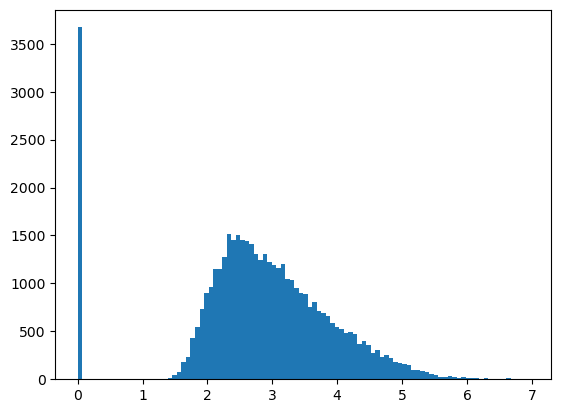

MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.3402872811244513, 'r_min': 1.072229824899561, 'r_core': 1.3402872811244513, 'r_cut': 4.020861843373353, 'volume': 10.085148518309495}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.3798635846442628, 'r_min': 1.1038908677154102, 'r_core': 1.3798635846442628, 'r_cut': 4.139590753932788, 'volume': 11.005177963849375}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 1.400309057827394, 'r_min': 1.1202472462619153, 'r_core': 1.400309057827394, 'r_cut': 4.200927173482182, 'volume': 11.50165412346837}, 4: {'species_id': 4, 'original_symbol': 'Li', 'symbol': 'Be', 'r_atom': 1.1155926499930506, 'r_min': 0.8924741199944406, 'r_core': 1.1155926499930506, 'r_cut': 3.3467779499791517, 'volume': 5.815747493087527}, 5: {'species_id': 5, 'original_symbol': 'Li', 'symbol': 'B',

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  47.47190298298526  CURRENT:  47.43776279651584
331 0.03414018646942196 min dist:  1.2283673777023576 ***** 311 311 1 1.2283673777023576
ACCEPT BY CRITERION
Atoms(symbols='Cl6Li6', pbc=True, cell=[[8.332339104756539, 0.0, 0.0], [2.824511199118026, 6.028950201946743, 0.0], [2.380935704605037, -1.088901607347992, 5.507967191972211]], tags=...)
./configs//Cl6Li6.e.23.vasp
K= 13.109994191499954 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.0661463533595046, 'r_min': 0.8529170826876037, 'r_core': 1.0661463533595046, 'r_cut': 3.1984390600785138, 'volume': 5.076204230142091}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.568797680106791, 'r_min': 1.255038144085433, 'r_core': 1.568797680106791, 'r_cut': 4.706393040320373, 'volume': 16.1729567300453}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  47.62865787173061  CURRENT:  47.55520948789386
334 0.07344838383674812 min dist:  1.2440786499633403 ***** 314 314 1 1.2440786499633403
ACCEPT BY CRITERION
Atoms(symbols='Li12', pbc=True, cell=[[10.294891819929317, 0.0, 0.0], [0.6306595757023529, 5.463174784524247, 0.0], [3.0977045479984153, 0.3197398399981927, 5.470621032968098]], tags=...)
./configs//Li12.e.23.vasp
K= 13.109994191499954 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.6399141467579925, 'r_min': 1.311931317406394, 'r_core': 1.6399141467579925, 'r_cut': 4.919742440273978, 'volume': 18.473617461268677}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.6293165291854796, 'r_min': 1.3034532233483838, 'r_core': 1.6293165291854796, 'r_cut': 4.887949587556439, 'volume': 18.11778073663823}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom'

...

CANDIDATE:  47.17245103331736  CURRENT:  47.400205117705035
340 -0.22775408438767641 min dist:  1.2221632716634587 ***** 318 318 1 1.2221632716634587
ACCEPT BY CRITERION
Atoms(symbols='Cl11Li', pbc=True, cell=[[6.374616627525992, 0.0, 0.0], [2.781371010491967, 6.294648674749126, 0.0], [1.2923976143016727, 0.5403496792303555, 4.358475050417548]], tags=...)
./configs//Cl11Li.e.25.vasp
K= 14.420993610649951 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.2325008147512653, 'r_min': 0.9860006518010123, 'r_core': 1.2325008147512653, 'r_cut': 3.6975024442537956, 'volume': 7.842422839506933}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.8029747903388398, 'r_min': 0.6423798322710719, 'r_core': 0.8029747903388398, 'r_cut': 2.4089243710165196, 'volume': 2.168674342221855}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  47.17361106669546  CURRENT:  47.17245103331736
341 0.0011600333780990013 min dist:  1.2370722740060074 ***** 319 319 1 1.2370722740060074
ACCEPT BY CRITERION
Atoms(symbols='Cl12', pbc=True, cell=[[9.730985839536206, 0.0, 0.0], [0.5569841601533826, 4.401977529539148, 0.0], [0.39897815592975705, 0.2315234617148525, 4.116097557775704]], tags=...)
./configs//Cl12.e.23.vasp
K= 14.420993610649951 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.8507834389951549, 'r_min': 0.6806267511961239, 'r_core': 0.8507834389951549, 'r_cut': 2.5523503169854647, 'volume': 2.5795603440259307}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 0.8344403092233251, 'r_min': 0.6675522473786601, 'r_core': 0.8344403092233251, 'r_cut': 2.5033209276699755, 'volume': 2.4337414305529155}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  46.65191625722476  CURRENT:  47.05673529988651
344 -0.4048190426617495 min dist:  1.2074042045263809 ***** 322 322 1 1.2074042045263809
ACCEPT BY CRITERION
Atoms(symbols='Cl11Li', pbc=True, cell=[[8.709304070894358, 0.0, 0.0], [1.539935987831664, 5.0261198204856825, 0.0], [1.3387484071613112, 0.33594518550711794, 3.4564444110183623]], tags=...)
./configs//Cl11Li.e.26.vasp
K= 14.420993610649951 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 0.7743317911267269, 'r_min': 0.6194654329013816, 'r_core': 0.7743317911267269, 'r_cut': 2.3229953733801807, 'volume': 1.9447773133871744}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.1032140957117422, 'r_min': 0.8825712765693938, 'r_core': 1.1032140957117422, 'r_cut': 3.309642287135227, 'volume': 5.624294015668287}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', '

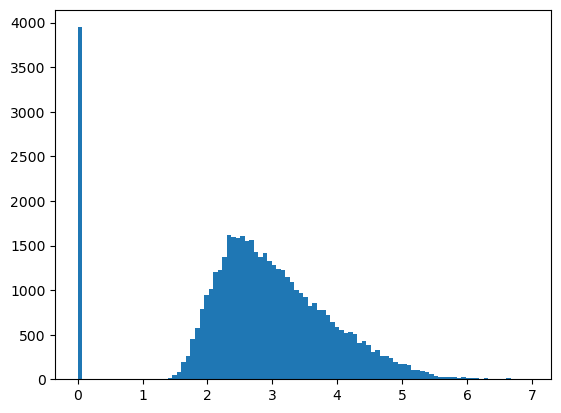

MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.3260405441863679, 'r_min': 1.0608324353490943, 'r_core': 1.3260405441863679, 'r_cut': 3.9781216325591036, 'volume': 9.766951210567221}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.165477530654629, 'r_min': 0.9323820245237032, 'r_core': 1.165477530654629, 'r_cut': 3.4964325919638872, 'volume': 6.631325176863078}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom': 0.993251226507791, 'r_min': 0.7946009812062328, 'r_core': 0.993251226507791, 'r_cut': 2.979753679523373, 'volume': 4.104553675551583}, 4: {'species_id': 4, 'original_symbol': 'Li', 'symbol': 'Be', 'r_atom': 1.599173200359031, 'r_min': 1.279338560287225, 'r_core': 1.599173200359031, 'r_cut': 4.797519601077093, 'volume': 17.130700351960435}, 5: {'species_id': 5, 'original_symbol': 'Li', 'symbol': 'B', 'r_

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  46.53687952931411  CURRENT:  46.535460970489495
356 0.0014185588246178327 min dist:  1.2401189363820557 ***** 334 334 1 1.2401189363820557
ACCEPT BY CRITERION
Atoms(symbols='Cl12', pbc=True, cell=[[8.667992585516483, 0.0, 0.0], [0.6617093959865546, 3.237616527334851, 0.0], [1.578430197371819, 0.3757395908507424, 4.227991664056838]], tags=...)
./configs//Cl12.e.24.vasp
K= 15.863092971714948 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.4699411183694913, 'r_min': 1.175952894695593, 'r_core': 1.4699411183694913, 'r_cut': 4.409823355108474, 'volume': 13.304189580462195}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.2068360742444617, 'r_min': 0.9654688593955694, 'r_core': 1.2068360742444617, 'r_cut': 3.620508222733385, 'volume': 7.362638197855083}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_atom

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  44.659340145417815  CURRENT:  44.86500800466228
367 -0.20566785924446407 min dist:  1.197094492861549 ***** 343 343 1 1.197094492861549
ACCEPT BY CRITERION
Atoms(symbols='Cl11Li', pbc=True, cell=[[8.294696230864023, 0.0, 0.0], [3.1995602295185335, 6.452064583927124, 0.0], [2.417814061593801, 0.47191397668977525, 4.1986032623905025]], tags=...)
./configs//Cl11Li.e.29.vasp
K= 17.449402268886445 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.256370438101005, 'r_min': 1.0050963504808041, 'r_core': 1.256370438101005, 'r_cut': 3.7691113143030153, 'volume': 8.306952679388193}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.534232278879899, 'r_min': 1.2273858231039192, 'r_core': 1.534232278879899, 'r_cut': 4.602696836639697, 'volume': 15.127318689021033}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_ato

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  44.57195486041971  CURRENT:  44.54016283758171
370 0.031792022837997536 min dist:  1.2352284879863886 ***** 346 346 1 1.2352284879863886
ACCEPT BY CRITERION
Atoms(symbols='Cl7Li5', pbc=True, cell=[[8.285824382793454, 0.0, 0.0], [1.3269861876247084, 5.697934584258429, 0.0], [2.1972929667799215, -0.10970475522409137, 4.772215355522466]], tags=...)
./configs//Cl7Li5.e.27.vasp
K= 17.449402268886445 0 0
MendeleevUniformRadiusSampler  ('Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.6158662705868008, 'r_min': 1.2926930164694408, 'r_core': 1.6158662705868008, 'r_cut': 4.8475988117604025, 'volume': 17.67277939052383}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.042608643720353, 'r_min': 0.8340869149762824, 'r_core': 1.042608643720353, 'r_cut': 3.127825931161059, 'volume': 4.747364442670246}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_

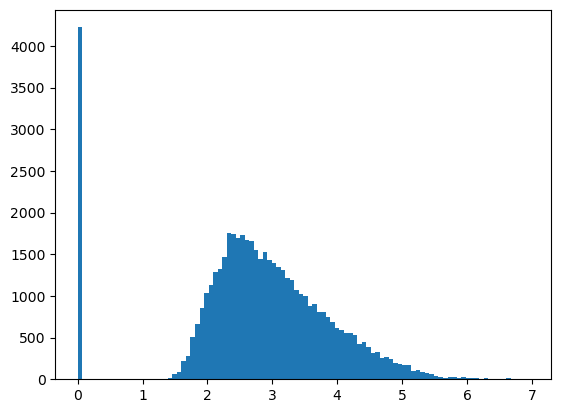

MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.0532670570090854, 'r_min': 0.8426136456072684, 'r_core': 1.0532670570090854, 'r_cut': 3.159801171027256, 'volume': 4.8944524342674525}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.1999091584860853, 'r_min': 0.9599273267888683, 'r_core': 1.1999091584860853, 'r_cut': 3.5997274754582556, 'volume': 7.236585768999023}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom': 1.2411244978543932, 'r_min': 0.9928995982835146, 'r_core': 1.2411244978543932, 'r_cut': 3.7233734935631793, 'volume': 8.008195250518746}, 4: {'species_id': 4, 'original_symbol': 'Cl', 'symbol': 'Be', 'r_atom': 0.7319471840938775, 'r_min': 0.585557747275102, 'r_core': 0.7319471840938775, 'r_cut': 2.1958415522816326, 'volume': 1.6425849612012908}, 5: {'species_id': 5, 'original_symbol': 'Cl', 'symbol': 

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  44.64298086061507  CURRENT:  44.67557795818351
376 -0.03259709756844131 min dist:  1.2224073415360215 ***** 352 352 1 1.2224073415360215
ACCEPT BY CRITERION
Atoms(symbols='Cl12', pbc=True, cell=[[3.806156171561006, 0.0, 0.0], [0.9052296228881371, 6.657174634280347, 0.0], [1.9086663599968337, 1.4278234651347623, 4.855862112517488]], tags=...)
./configs//Cl12.e.26.vasp
K= 19.19434249577509 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.1498483799976456, 'r_min': 0.9198787039981164, 'r_core': 1.1498483799976456, 'r_cut': 3.449545139992937, 'volume': 6.368106858275548}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.1404308547594422, 'r_min': 0.9123446838075537, 'r_core': 1.1404308547594422, 'r_cut': 3.4212925642783265, 'volume': 6.212916053903544}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', 'r_atom'

/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/ase/utils/linesearch.py:235: RuntimeWarning: invalid value encountered in double_scalars
  sign = gp * (gx / abs(gx))


CANDIDATE:  43.907622863823164  CURRENT:  43.893398811548266
384 0.014224052274897758 min dist:  1.2296168646243804 ***** 360 360 1 1.2296168646243804
ACCEPT BY CRITERION
Atoms(symbols='Cl7Li5', pbc=True, cell=[[6.356391111630041, 0.0, 0.0], [2.225257456021038, 7.6831135600045615, 0.0], [0.40385913067341805, 1.6253010013691596, 4.459777153242545]], tags=...)
./configs//Cl7Li5.e.29.vasp
K= 19.19434249577509 0 0
MendeleevUniformRadiusSampler  ('Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Li', 'Li', 'Li', 'Li')
{1: {'species_id': 1, 'original_symbol': 'Cl', 'symbol': 'H', 'r_atom': 1.0662532789106958, 'r_min': 0.8530026231285567, 'r_core': 1.0662532789106958, 'r_cut': 3.198759836732087, 'volume': 5.077731685649275}, 2: {'species_id': 2, 'original_symbol': 'Cl', 'symbol': 'He', 'r_atom': 1.0997366999308198, 'r_min': 0.8797893599446559, 'r_core': 1.0997366999308198, 'r_cut': 3.299210099792459, 'volume': 5.5712771620358135}, 3: {'species_id': 3, 'original_symbol': 'Cl', 'symbol': 'Li', '

KeyboardInterrupt: 

Exception ignored in: 'mliap_model_python_couple.MLIAPPY_compute_gradients'
Traceback (most recent call last):
  File "/home/d_perez/notebooks/entropy/entropy_utils.py", line 208, in __call__
    b = self.K*self.cn_grad(b)
  File "/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/jax/_src/traceback_util.py", line 162, in reraise_with_filtered_traceback
    return fun(*args, **kwargs)
  File "/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/jax/_src/api.py", line 1089, in grad_f
    _, g = value_and_grad_f(*args, **kwargs)
  File "/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/jax/_src/traceback_util.py", line 162, in reraise_with_filtered_traceback
    return fun(*args, **kwargs)
  File "/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/jax/_src/api.py", line 1165, in value_and_grad_f
    ans, vjp_py = _vjp(f_partial, *dyn_args, reduce_axes=reduce_axes)
  File "/home/d_perez/anaconda3/envs/jax/lib/python3.8/site-packages/jax/_src/api.py",

CANDIDATE:  43.896374715735284  CURRENT:  43.907622863823164
385 -0.011248148087879883 min dist:  1.230426900858432 ***** 361 361 1 1.230426900858432
ACCEPT BY CRITERION
Atoms(symbols='Cl8Li4', pbc=True, cell=[[8.486128338406589, 0.0, 0.0], [1.3385526524181224, 4.489453652683261, 0.0], [1.962369253622044, -0.35327388928375386, 6.747763435238109]], tags=...)
./configs//Cl8Li4.e.23.vasp
K= 19.19434249577509 0 0
MendeleevUniformRadiusSampler  ('Li', 'Li', 'Li', 'Li', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl')
{1: {'species_id': 1, 'original_symbol': 'Li', 'symbol': 'H', 'r_atom': 1.335240995862466, 'r_min': 1.068192796689973, 'r_core': 1.335240995862466, 'r_cut': 4.005722987587398, 'volume': 9.971662783140163}, 2: {'species_id': 2, 'original_symbol': 'Li', 'symbol': 'He', 'r_atom': 1.4984736037243866, 'r_min': 1.1987788829795094, 'r_core': 1.4984736037243866, 'r_cut': 4.49542081117316, 'volume': 14.094053005632672}, 3: {'species_id': 3, 'original_symbol': 'Li', 'symbol': 'Li', 'r_ato

In [ ]:
from ase.optimize.bfgslinesearch import BFGSLineSearch
from ase.md.verlet import VelocityVerlet
from ase import units
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.md.langevin import Langevin
    
import ase.io.lammpsdata
import os
import glob
from ase.io import read,write



#aggregates the mean and covariances from multiple configurations
manager=entropy_utils.CNManager(n_descriptors_tot,energy_mode=energy_mode,mean=mean,renorm=renorm,epsilon=epsilon)

raw_data=[]
    
current_det=0

n_reject_improve=0
n_reject_dist=0
i_accept=0
n_accept=0

K=K_init

if not os.path.exists(output_prefix):
    os.makedirs(output_prefix) 


if energy_mode:
    files = glob.glob(output_prefix+'dopti-energy.*')
else:
    files = glob.glob(output_prefix+'dopti-forces.*')
for f in files:
    os.remove(f)


i=0

bond_lengths=[]
counter_dict={}

for iii in range(1):
    i_accept_batch=0
    for ii in range(trials_per_cycle):

        mask=None
        #mask=random.choices(base_mask,k=n_descriptors_sample)
        #mask.sort()
        #print("MASK: ",mask)
        rr,rr_by_symbol=sample_radii(n_atoms)
        atom_types={ k:v['species_id'] for k,v in rr_by_symbol.items() }
        print(rr)

        specorder=[v['symbol'] for k,v in rr.items()]
        generate_min,generate_zero,snap_descriptors=entropy_utils.generate_lammps_scripts(rr,"./test")

        i+=1
        shape=random.choice(shapes)
        #n_at=random.choice(n_atoms)
        n_at=n_atoms
        
        species_list=[rr[k]['symbol'] for k in rr.keys() ]
        #sampled_species=np.random.choice(species_list, n_at, replace=True)
        sampled_species=species_list
        sampled_species.sort()
        
        #print(sampled_species)
        
        #print(generate_min,n_Be)
        calculator_min = entropy_utils.EntropyCalculator(lmpcmds=generate_min.split("\n"), log_file="lammps.log", model=model, keep_alive=True, atom_types=atom_types)



        target_volume=0.
        for s in sampled_species:
            target_volume+=rr_by_symbol[s]['volume']/len(sampled_species)
        target_volume=np.random.uniform(low=volume_scaling[0],high=volume_scaling[1])*target_volume


        indices=list(range(n_at))
        populations={}
        populations[1]=indices
        model=entropy_utils.CNModel(n_atoms, n_descriptors_tot, energy_mode=energy_mode, populations=None, mask=mask, cross_=manager.cross, renorm_=renorm, mean_=mean, count_=manager.count, epsilon_=epsilon)

    
        if i_accept<10:
            model.active=False
            model.K=0.0
        else: 
            model.active=True
            model.K=K

            
        from  ase.calculators.lammpslib import LAMMPSlib
        calculator_relax=LAMMPSlib(lmpcmds=generate_zero.split("\n"), log_file=None,keep_alive=True,atom_types=atom_types)
        calculator_min = entropy_utils.EntropyCalculator(lmpcmds=generate_min.split("\n"), log_file=None, model=model, keep_alive=True,atom_types=atom_types)
        
        ntry=0
        while ntry<10:
            try:
                atoms = entropy_utils.generate_random_cell(rr, sampled_species, target_volume=target_volume, shape=shape)
                ntry+=1
                break
            except:
                ntry+=1
                pass


        

        if not ntry==10:

            dists+=1000*np.identity(n_at)
            species_index_map={ v['symbol']:k for k,v in rr.items() }
            for a1 in range(len(atoms)):
                for a2 in range(len(atoms)):
                    dists[a1,a2]/=(rr[species_index_map[sampled_species[a1]]]["r_min"]+rr[species_index_map[sampled_species[a2]]]["r_min"])
                
            print("As prepared min dist: ",np.min(dists))
            


            #print(atom_numbers)
            #print(atoms)

            atoms.calc=calculator_relax
            #relax with the core repulsion alone
            opt = BFGSLineSearch(atoms, force_consistent=True,logfile=None)
            opt.run(fmax=0.05, steps=30)

            
            import pickle
            if i%10==0:
                if energy_mode:
                    pickle.dump( manager.data, open( output_prefix+"d-opti-energy.p", "wb" ) )
                else:
                    pickle.dump( manager.data, open( output_prefix+"d-opti-forces.p", "wb" ) )
                    
            atoms.calc=calculator_min
            opt = BFGSLineSearch(atoms, force_consistent=True,logfile=None)
            opt.run(fmax=0.05, steps=100)
                
                
            d=entropy_utils.compute_descriptors(atoms)
            cand_cond,cand_det=manager.evaluate(d)
                
            if i>1:
                print("CANDIDATE: ",cand_det, " CURRENT: ",current_det)
            
            dists=atoms.get_all_distances(mic=True)
            dists+=1000*np.identity(n_at)


            species_index_map={ v['symbol']:k for k,v in rr.items() }
            for a1 in range(len(atoms)):
                for a2 in range(len(atoms)):
                    dists[a1,a2]/=(rr[species_index_map[sampled_species[a1]]]["r_min"]+rr[species_index_map[sampled_species[a2]]]["r_min"])
            
            print(i,cand_det-current_det, "min dist: ",np.min(dists),end=" ")
            

            
            if np.min(dists) < 1:
                n_reject_dist+=1
            
            if cand_det>current_det:
                n_reject_improve+=1

            
                

            print("*****", i_accept, i_accept_batch, min_accept_per_cycle, np.min(dists) )
            if (i_accept<=10 or i_accept_batch<min_accept_per_cycle) and np.min(dists) > 1:
                print("ACCEPT BY DEFAULT")
                manager.update(d)
                current_cond,current_det=manager.evaluate()

                mapping={}
                original_species=atoms.get_chemical_symbols()
                for k,v in rr.items():
                    mapping[v['symbol']]=v['original_symbol']

                remapped_species=[mapping[k] for k in original_species]
                #print(remapped_species)
                atoms.set_chemical_symbols(remapped_species)
                atoms=ase.build.sort(atoms)
                print(atoms)
                #print(atoms.symbols)
                s=atoms.symbols.get_chemical_formula()
                if s in counter_dict:
                    counter_dict[s]+=1
                else:
                    counter_dict[s]=0
                if energy_mode:
                    s2=".e"
                else:
                    s2=".f"

                #output_file=str(Path(c).parents[0])+"/"+Path(c).stem + ".vasp"
                output_file=str(output_prefix+"/"+s+s2+(".%i"%counter_dict[s]))+".vasp"
                print(output_file)
                write(output_file,atoms,format='vasp')
                
                """
                if energy_mode:
                    ase.io.lammpsdata.write_lammps_data(output_prefix+"dopti-energy.%i.dat" % i_accept ,atoms,specorder=specorder)
                    pickle.dump(rr,open(output_prefix+"dopti-energy.%i.settings" % i_accept,"wb" ) )

                else:
                    ase.io.lammpsdata.write_lammps_data(output_prefix+"dopti-forces.%i.dat" % i_accept ,atoms,specorder=specorder)
                    pickle.dump(rr,open(output_prefix+"dopti-forces.%i.settings" % i_accept,"wb" ))
                """

                i_accept+=1
                i_accept_batch+=1
                dists=atoms.get_all_distances(mic=True)
                bond_lengths+=dists.flatten().tolist()


            else:
                #if cand_det < current_det and np.min(dists) > min_distance:
                if np.min(dists) > 1 and ( (strict_entropy_decrease and cand_det < current_det ) or not strict_entropy_decrease):
                    print("ACCEPT BY CRITERION")

                    #if np.min(dists) > min_distance:
                    n_reject_dist=0
                    n_reject_improve=0
                    manager.update(d)
                    current_cond,current_det=manager.evaluate()
                    #print("***CANDIDATE: ",cand_cond,cand_det, " CURRENT: ", current_cond,current_det)

                    mapping={}
                    original_species=atoms.get_chemical_symbols()
                    for k,v in rr.items():
                        mapping[v['symbol']]=v['original_symbol']

                    remapped_species=[mapping[k] for k in original_species]
                    #print(remapped_species)
                    atoms.set_chemical_symbols(remapped_species)
                    atoms=ase.build.sort(atoms)
                    print(atoms)
                    #print(atoms.symbols)
                    s=atoms.symbols.get_chemical_formula()
                    if s in counter_dict:
                        counter_dict[s]+=1
                    else:
                        counter_dict[s]=0

                    #output_file=str(Path(c).parents[0])+"/"+Path(c).stem + ".vasp"
                    if energy_mode:
                        s2=".e"
                    else:
                        s2=".f"

                    output_file=str(output_prefix+"/"+s+s2+(".%i"%counter_dict[s]))+".vasp"
                    print(output_file)
                    write(output_file,atoms,format='vasp')
                    #count+=1

                    """
                    if energy_mode:
                        ase.io.lammpsdata.write_lammps_data(output_prefix+"dopti-energy.%i.dat" % i_accept ,atoms,specorder=specorder)
                        pickle.dump(rr,open(output_prefix+"dopti-energy.%i.settings" % i_accept,"wb" ) )
                    else:
                        ase.io.lammpsdata.write_lammps_data(output_prefix+"dopti-forces.%i.dat" % i_accept ,atoms,specorder=specorder)
                        pickle.dump(rr,open(output_prefix+"dopti-forces.%i.settings" % i_accept,"wb" ))
                    """

                    i_accept+=1
                    n_accept+=1
                    i_accept_batch+=1
                
                    dists=atoms.get_all_distances(mic=True)
                    bond_lengths+=dists.flatten().tolist()
                else:
                    print("REJECTED")
                    print()
                
            if i%10==0:
                pass
                #manager.print_status()
                
            if n_reject_improve>10:
                K*=1.2
                n_reject_improve=0
                n_reject_dist=0
            if n_reject_dist>10:
                K*=0.8
                n_reject_improve=0
                n_reject_dist=0
            if n_accept>10:
                K*=1.1
                n_accept=0
                
                
            print("K=",K, n_reject_improve,n_reject_dist,model.count)
            if i_accept>500:
                break
            
            
            
            
            
            if i%25==0 and not manager.s is None:
                #plt.figure()
                #plt.semilogy(manager.s)
                #plt.show()

                plt.figure()
                plt.hist(bond_lengths,bins=100)
                plt.show()
            
        
    

In [ ]:
#dists.flatten()

In [ ]:
#import pickle
#pickle.dump( manager.data, open( "d-opti.p", "wb" ) )